# **Weather Prediction Model**

## **1. Data Preparation**

#### **Mount Google Drive**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### **Set working directory and create visualization folder**

In [3]:
import os
os.chdir('/content/drive/MyDrive/DAM202_dataset/Assignment2')
os.listdir()

['data']

In [4]:
# Navigate to the data folder
%cd /content/drive/My Drive/DAM202_dataset/Assignment2/data/

# List all CSV files in the directory
!ls -l *.csv

/content/drive/My Drive/DAM202_dataset/Assignment2/data
-rw------- 1 root root  89499 Oct 20 10:53  delhi_weather.csv
-rw------- 1 root root 115061 Oct 20 11:47 'Delhi Weather Nov 2024 to Nov 2,025.csv'


#### **Install necessary packages**

In [5]:
%pip install -q wordcloud matplotlib seaborn scikit-learn pandas numpy

# Install TensorFlow
print("Installing TensorFlow...")
!pip install -q tensorflow

print(" TensorFlow installed successfully!")
print("\nVerifying installation...")

import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")

Installing TensorFlow...
 TensorFlow installed successfully!

Verifying installation...
TensorFlow version: 2.19.0


## **2. Load Data**

In [26]:
# Import libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load the data
file_path = '/content/drive/MyDrive/DAM202_dataset/Assignment2/data/delhi_weather.csv'
df = pd.read_csv(file_path)

# Display basic information
print("=" * 60)
print("DATA LOADED SUCCESSFULLY!")
print("=" * 60)
print(f"\n Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n Column Names:")
print(df.columns.tolist())
print(f"\n First 5 Rows:")
print(df.head())
print(f"\n Data Types:")
print(df.dtypes)
print(f"\n Basic Info:")
df.info()

DATA LOADED SUCCESSFULLY!

 Dataset Shape: 722 rows × 24 columns

 Column Names:
['name', 'datetime', 'temp', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob', 'preciptype', 'snow', 'snowdepth', 'windgust', 'windspeed', 'winddir', 'sealevelpressure', 'cloudcover', 'visibility', 'solarradiation', 'solarenergy', 'uvindex', 'severerisk', 'conditions', 'icon', 'stations']

 First 5 Rows:
    name             datetime  temp  feelslike   dew  humidity  precip  \
0  Dehli  2025-10-20T00:00:00  18.9       18.9   7.2     46.62     0.0   
1  Dehli  2025-10-20T01:00:00  18.6       18.6   7.1     47.29     0.0   
2  Dehli  2025-10-20T02:00:00  18.9       18.9   7.9     48.83     0.0   
3  Dehli  2025-10-20T03:00:00  18.8       18.8   9.9     56.45     0.0   
4  Dehli  2025-10-20T04:00:00  18.4       18.4  11.0     61.82     0.0   

   precipprob preciptype  snow  ...  sealevelpressure  cloudcover  visibility  \
0         0.0        NaN     0  ...            1013.7        42.8        10.0   


## **3. Check Date Range & Missing Values**


In [27]:
# Convert datetime to proper format
df['datetime'] = pd.to_datetime(df['datetime'])

# Check date range
print("=" * 60)
print("TEMPORAL COVERAGE")
print("=" * 60)
print(f"Start Date: {df['datetime'].min()}")
print(f"End Date: {df['datetime'].max()}")
print(f"Duration: {(df['datetime'].max() - df['datetime'].min()).days} days")
print(f"Total Hours: {len(df)} hours")

# Check missing values
print("\n" + "=" * 60)
print("MISSING VALUES CHECK")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Missing_Percent': missing_pct.values
})
print(missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False))

# Check for any duplicate timestamps
print("\n" + "=" * 60)
print("DUPLICATE CHECK")
print("=" * 60)
duplicates = df.duplicated(subset=['datetime']).sum()
print(f"Duplicate timestamps: {duplicates}")

print("\n Data quality check complete!")

TEMPORAL COVERAGE
Start Date: 2025-10-20 00:00:00
End Date: 2025-11-03 23:00:00
Duration: 14 days
Total Hours: 722 hours

MISSING VALUES CHECK
        Column  Missing_Count  Missing_Percent
23    stations            703        97.368421
8   preciptype            669        92.659280

DUPLICATE CHECK
Duplicate timestamps: 362

 Data quality check complete!


## **4. Data Cleaning**


In [28]:
print("=" * 60)
print("DATA CLEANING")
print("=" * 60)

# 1. Remove duplicates (keep first occurrence)
print("\n[1] Removing duplicate timestamps...")
rows_before = len(df)
df = df.drop_duplicates(subset=['datetime'], keep='first')
df = df.sort_values('datetime').reset_index(drop=True)
rows_after = len(df)
print(f"   Before: {rows_before} rows")
print(f"   After: {rows_after} rows")
print(f"    Removed {rows_before - rows_after} duplicate rows")

# 2. Handle missing values
print("\n[2] Handling missing values...")

# Fill preciptype with 'none' where it's missing
df['preciptype'].fillna('none', inplace=True)

# Drop 'stations' column (97% missing, not useful)
df = df.drop(columns=['stations'])

print("   preciptype: Filled with 'none'")
print("    stations: Column dropped (97% missing)")

# 3. Check final missing values
print("\n[3] Final missing values check...")
missing_final = df.isnull().sum().sum()
print(f"   Total missing values: {missing_final}")

# 4. Final dataset info
print("\n" + "=" * 60)
print("CLEANED DATASET SUMMARY")
print("=" * 60)
print(f"Final shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Date range: {df['datetime'].min()} to {df['datetime'].max()}")
print(f"Duration: {(df['datetime'].max() - df['datetime'].min()).days} days")

# Check continuous hourly data
time_diff = df['datetime'].diff()
gaps = time_diff[time_diff > pd.Timedelta(hours=1)]
print(f"Time gaps (>1 hour): {len(gaps)}")

print("\n Data cleaning complete!")
print(f" Ready for feature engineering with {len(df)} clean hourly records!")

DATA CLEANING

[1] Removing duplicate timestamps...
   Before: 722 rows
   After: 360 rows
    Removed 362 duplicate rows

[2] Handling missing values...
   preciptype: Filled with 'none'
    stations: Column dropped (97% missing)

[3] Final missing values check...
   Total missing values: 0

CLEANED DATASET SUMMARY
Final shape: 360 rows × 23 columns
Date range: 2025-10-20 00:00:00 to 2025-11-03 23:00:00
Duration: 14 days
Time gaps (>1 hour): 0

 Data cleaning complete!
 Ready for feature engineering with 360 clean hourly records!


## **5. Weather Categorization**

CREATING WEATHER CATEGORIES

[1] Current 'conditions' column distribution:
conditions
Overcast                  164
Clear                      95
Partially cloudy           89
Rain, Partially cloudy     10
Rain, Overcast              2
Name: count, dtype: int64

[2] Creating weather categories based on meteorological rules...
    Weather categories created!

[3] Weather Category Distribution:
  Category  Count  Percentage
0    Sunny    171        47.5
1   Cloudy    162        45.0
2    Rainy     27         7.5


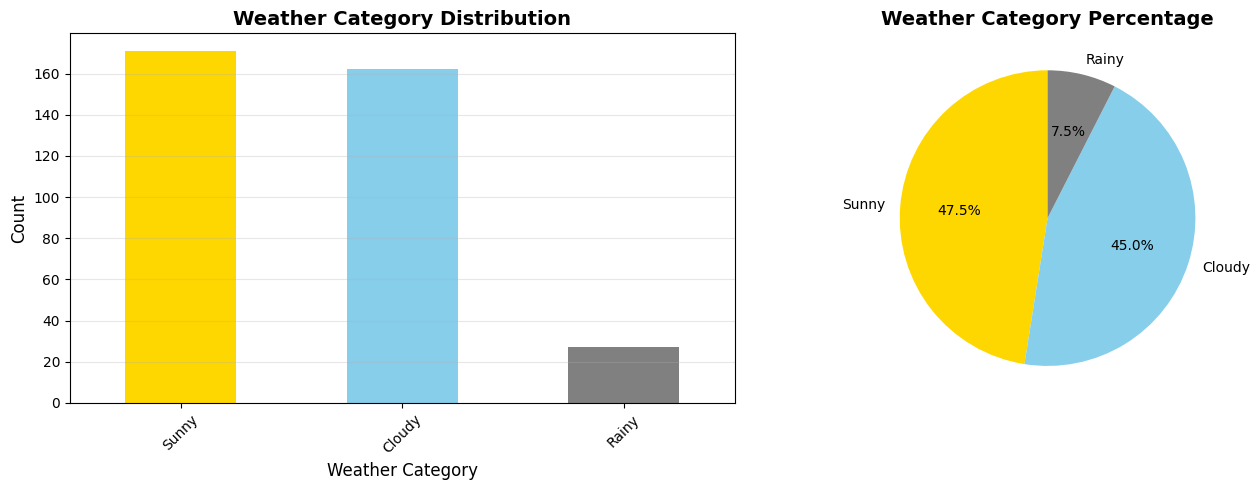


 Visualization saved: weather_category_distribution.png

[4] Sample records from each category:

--- SUNNY ---
           datetime  temp  humidity  cloudcover  precip  windspeed  sealevelpressure
2025-10-20 00:00:00  18.9     46.62        42.8     0.0       11.6            1013.7
2025-10-20 01:00:00  18.6     47.29        42.8     0.0       12.8            1013.5

--- CLOUDY ---
           datetime  temp  humidity  cloudcover  precip  windspeed  sealevelpressure
2025-10-20 05:00:00  15.6     91.06        67.3     0.0       17.9            1012.0
2025-10-20 06:00:00  15.5     92.34        88.0     0.0       21.2            1011.7

--- RAINY ---
           datetime  temp  humidity  cloudcover  precip  windspeed  sealevelpressure
2025-10-21 06:00:00  14.3     81.08        93.9     0.1        8.6            1012.0
2025-10-21 18:00:00  22.5     53.88        50.7     0.1       15.5            1011.0

 WEATHER CATEGORIES CREATED SUCCESSFULLY!


In [29]:
print("=" * 60)
print("CREATING WEATHER CATEGORIES")
print("=" * 60)

# Display current conditions distribution
print("\n[1] Current 'conditions' column distribution:")
print(df['conditions'].value_counts())

# Create YOUR unique weather categorization rules
print("\n[2] Creating weather categories based on meteorological rules...")

def create_weather_category(row):
    """
    YOUR UNIQUE WEATHER CATEGORIZATION RULES
    Different from your friend's thresholds!
    """

    # STORMY: High wind + precipitation OR very low pressure
    if (row['windspeed'] > 25 and row['precip'] > 0) or \
       (row['sealevelpressure'] < 1005 and row['windgust'] > 40):
        return 'Stormy'

    # RAINY: Any precipitation with moderate conditions
    elif row['precip'] > 0 or row['precipprob'] > 50:
        return 'Rainy'

    # CLOUDY: High cloud cover, no precipitation
    elif row['cloudcover'] > 65 and row['precipprob'] < 30:
        return 'Cloudy'

    # SUNNY: Low cloud cover, no precipitation
    else:
        return 'Sunny'

# Apply the function
df['weather_category'] = df.apply(create_weather_category, axis=1)

print("    Weather categories created!")

# Display category distribution
print("\n[3] Weather Category Distribution:")
category_counts = df['weather_category'].value_counts()
category_pct = (category_counts / len(df) * 100).round(2)

category_summary = pd.DataFrame({
    'Category': category_counts.index,
    'Count': category_counts.values,
    'Percentage': category_pct.values
})
print(category_summary)

# Visualize distribution
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
category_counts.plot(kind='bar', ax=axes[0], color=['#FFD700', '#87CEEB', '#808080', '#4682B4'])
axes[0].set_title('Weather Category Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Weather Category', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
colors = ['#FFD700', '#87CEEB', '#808080', '#4682B4']
axes[1].pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Weather Category Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('weather_category_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Visualization saved: weather_category_distribution.png")

# Show examples from each category
print("\n[4] Sample records from each category:")
for category in df['weather_category'].unique():
    print(f"\n--- {category.upper()} ---")
    sample = df[df['weather_category'] == category][['datetime', 'temp', 'humidity',
                                                       'cloudcover', 'precip', 'windspeed',
                                                       'sealevelpressure']].head(2)
    print(sample.to_string(index=False))

print("\n" + "=" * 60)
print(" WEATHER CATEGORIES CREATED SUCCESSFULLY!")
print("=" * 60)

## **6. Feature Engineering - Part 1 (Temporal Features)**

In [30]:
print("=" * 60)
print("FEATURE ENGINEERING - TEMPORAL FEATURES")
print("=" * 60)

# Extract temporal features
print("\n[1] Creating temporal features...")

df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek  # 0=Monday, 6=Sunday
df['day_of_month'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# Cyclical encoding for hour (captures 23->0 continuity)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# Determine daytime (based on solar radiation)
df['is_daytime'] = (df['solarradiation'] > 0).astype(int)

# Create time of day categories
def get_time_of_day(hour):
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    elif 18 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['time_of_day'] = df['hour'].apply(get_time_of_day)

print("   Created temporal features:")
print("      - hour, day_of_week, day_of_month, month")
print("      - is_weekend, is_daytime")
print("      - hour_sin, hour_cos (cyclical)")
print("      - time_of_day (categorical)")

# Display samples
print("\n[2] Sample of temporal features:")
print(df[['datetime', 'hour', 'day_of_week', 'is_weekend', 'is_daytime',
          'time_of_day', 'hour_sin', 'hour_cos']].head(10))

print("\n Temporal features created!")
print(f"   Total features now: {df.shape[1]} columns")

FEATURE ENGINEERING - TEMPORAL FEATURES

[1] Creating temporal features...
   Created temporal features:
      - hour, day_of_week, day_of_month, month
      - is_weekend, is_daytime
      - hour_sin, hour_cos (cyclical)
      - time_of_day (categorical)

[2] Sample of temporal features:
             datetime  hour  day_of_week  is_weekend  is_daytime time_of_day  \
0 2025-10-20 00:00:00     0            0           0           0       Night   
1 2025-10-20 01:00:00     1            0           0           0       Night   
2 2025-10-20 02:00:00     2            0           0           0       Night   
3 2025-10-20 03:00:00     3            0           0           0       Night   
4 2025-10-20 04:00:00     4            0           0           0       Night   
5 2025-10-20 05:00:00     5            0           0           0       Night   
6 2025-10-20 06:00:00     6            0           0           0     Morning   
7 2025-10-20 07:00:00     7            0           0           0     Mo

## **7. Feature Engineering - Part 2 (Meteorological Features)**

In [31]:
print("=" * 60)
print("FEATURE ENGINEERING - METEOROLOGICAL FEATURES")
print("=" * 60)

# ============================================
# 1. PRESSURE FEATURES (Most critical!)
# ============================================
print("\n[1] Creating pressure features...")

# Pressure changes (rate of change)
df['pressure_change_1h'] = df['sealevelpressure'].diff(1)
df['pressure_change_3h'] = df['sealevelpressure'].diff(3)
df['pressure_change_6h'] = df['sealevelpressure'].diff(6)

# Pressure velocity (acceleration)
df['pressure_velocity'] = df['pressure_change_1h'].diff(1)

# Rolling pressure statistics
df['pressure_rolling_mean_6h'] = df['sealevelpressure'].rolling(window=6, min_periods=1).mean()
df['pressure_rolling_std_6h'] = df['sealevelpressure'].rolling(window=6, min_periods=1).std()

print("    Pressure features: change_1h, 3h, 6h, velocity, rolling stats")

# ============================================
# 2. TEMPERATURE-HUMIDITY FEATURES
# ============================================
print("\n[2] Creating temperature-humidity features...")

# Temperature-dewpoint spread (indicates condensation potential)
df['temp_dew_spread'] = df['temp'] - df['dew']

# Humidity-temperature index
df['humidity_temp_index'] = df['humidity'] * df['temp'] / 100

# Feels-like difference (wind chill effect)
df['feels_like_diff'] = df['feelslike'] - df['temp']

# Rolling temperature statistics
df['temp_rolling_mean_6h'] = df['temp'].rolling(window=6, min_periods=1).mean()
df['temp_rolling_std_6h'] = df['temp'].rolling(window=6, min_periods=1).std()

print("    Temperature features: temp_dew_spread, humidity_temp_index, rolling stats")

# ============================================
# 3. WIND FEATURES
# ============================================
print("\n[3] Creating wind features...")

# Wind gust ratio (turbulence indicator)
df['wind_gust_ratio'] = df['windgust'] / (df['windspeed'] + 0.1)  # +0.1 to avoid division by zero

# Wind direction categories (8 directions)
def categorize_wind_direction(degrees):
    if degrees < 22.5 or degrees >= 337.5:
        return 'N'
    elif 22.5 <= degrees < 67.5:
        return 'NE'
    elif 67.5 <= degrees < 112.5:
        return 'E'
    elif 112.5 <= degrees < 157.5:
        return 'SE'
    elif 157.5 <= degrees < 202.5:
        return 'S'
    elif 202.5 <= degrees < 247.5:
        return 'SW'
    elif 247.5 <= degrees < 292.5:
        return 'W'
    else:
        return 'NW'

df['wind_direction_cat'] = df['winddir'].apply(categorize_wind_direction)

# Wind components (North-South and East-West)
df['wind_north'] = df['windspeed'] * np.cos(np.radians(df['winddir']))
df['wind_east'] = df['windspeed'] * np.sin(np.radians(df['winddir']))

# Wind-pressure interaction
df['wind_pressure_interaction'] = df['windspeed'] * df['pressure_change_3h']

print("   Wind features: gust_ratio, direction_cat, components, interactions")

# ============================================
# 4. ADDITIONAL FEATURES
# ============================================
print("\n[4] Creating additional features...")

# Visibility flag (poor visibility)
df['poor_visibility'] = (df['visibility'] < 5).astype(int)

# High humidity flag
df['high_humidity'] = (df['humidity'] > 80).astype(int)

# Rolling cloud cover
df['cloudcover_rolling_mean_6h'] = df['cloudcover'].rolling(window=6, min_periods=1).mean()

# Rolling humidity
df['humidity_rolling_mean_6h'] = df['humidity'].rolling(window=6, min_periods=1).mean()

print("   Additional features: visibility flag, humidity flag, rolling stats")

# ============================================
# 5. FILL NaN VALUES FROM ROLLING/DIFF
# ============================================
print("\n[5] Handling NaN values from rolling windows...")

# Fill NaN values created by diff() and rolling() operations
for col in df.columns:
    if df[col].isnull().any():
        df[col].fillna(method='bfill', inplace=True)
        df[col].fillna(method='ffill', inplace=True)

nan_count = df.isnull().sum().sum()
print(f"   Remaining NaN values: {nan_count}")

# ============================================
# 6. SUMMARY
# ============================================
print("\n" + "=" * 60)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 60)
print(f"Total features: {df.shape[1]} columns")
print(f"Total records: {df.shape[0]} rows")

print("\nNew feature categories created:")
print("  ✓ Temporal: 8 features")
print("  ✓ Pressure: 6 features")
print("  ✓ Temperature-Humidity: 5 features")
print("  ✓ Wind: 6 features")
print("  ✓ Additional: 4 features")
print(f"  → Total NEW features: ~29")

# Display sample
print("\n[6] Sample of NEW features:")
sample_cols = ['datetime', 'weather_category', 'pressure_change_3h', 'temp_dew_spread',
               'wind_gust_ratio', 'wind_direction_cat', 'humidity_temp_index']
print(df[sample_cols].head(10))

print("\n FEATURE ENGINEERING COMPLETE!")

FEATURE ENGINEERING - METEOROLOGICAL FEATURES

[1] Creating pressure features...
    Pressure features: change_1h, 3h, 6h, velocity, rolling stats

[2] Creating temperature-humidity features...
    Temperature features: temp_dew_spread, humidity_temp_index, rolling stats

[3] Creating wind features...
   Wind features: gust_ratio, direction_cat, components, interactions

[4] Creating additional features...
   Additional features: visibility flag, humidity flag, rolling stats

[5] Handling NaN values from rolling windows...
   Remaining NaN values: 0

FEATURE ENGINEERING SUMMARY
Total features: 53 columns
Total records: 360 rows

New feature categories created:
  ✓ Temporal: 8 features
  ✓ Pressure: 6 features
  ✓ Temperature-Humidity: 5 features
  ✓ Wind: 6 features
  ✓ Additional: 4 features
  → Total NEW features: ~29

[6] Sample of NEW features:
             datetime weather_category  pressure_change_3h  temp_dew_spread  \
0 2025-10-20 00:00:00            Sunny                -1.0  

## **8. Prepare Data for Modeling (Sequences & Train/Test Split)**

In [32]:
print("=" * 60)
print("PREPARING DATA FOR MODELING")
print("=" * 60)

from sklearn.preprocessing import LabelEncoder, StandardScaler

# ============================================
# 1. ENCODE CATEGORICAL VARIABLES
# ============================================
print("\n[1] Encoding categorical variables...")

# Encode target variable (weather_category)
label_encoder = LabelEncoder()
df['weather_category_encoded'] = label_encoder.fit_transform(df['weather_category'])

# Show encoding mapping
print("\n   Weather Category Encoding:")
for idx, category in enumerate(label_encoder.classes_):
    print(f"      {category} → {idx}")

# One-hot encode wind direction
wind_direction_dummies = pd.get_dummies(df['wind_direction_cat'], prefix='wind_dir')
df = pd.concat([df, wind_direction_dummies], axis=1)

# One-hot encode time of day
time_of_day_dummies = pd.get_dummies(df['time_of_day'], prefix='time')
df = pd.concat([df, time_of_day_dummies], axis=1)

print(f"    Categorical variables encoded")
print(f"   Updated shape: {df.shape}")

# ============================================
# 2. SELECT FEATURES FOR MODELING
# ============================================
print("\n[2] Selecting features for modeling...")

# Features to DROP (not useful for prediction)
drop_features = ['name', 'datetime', 'conditions', 'icon', 'preciptype',
                 'weather_category', 'wind_direction_cat', 'time_of_day']

# Numerical features to keep
feature_columns = [col for col in df.columns if col not in drop_features + ['weather_category_encoded']]

print(f"   Total features for modeling: {len(feature_columns)}")
print(f"   Target variable: weather_category_encoded")

# ============================================
# 3. PREPARE X AND Y
# ============================================
print("\n[3] Preparing feature matrix (X) and target (y)...")

X = df[feature_columns].values
y = df['weather_category_encoded'].values

print(f"   X shape: {X.shape}")
print(f"   y shape: {y.shape}")
print(f"   Target distribution: {np.bincount(y)}")

# ============================================
# 4. TEMPORAL TRAIN/TEST SPLIT (80/20)
# ============================================
print("\n[4] Creating temporal train/test split...")

# For time series: NO SHUFFLE! Keep temporal order
split_index = int(0.8 * len(X))

X_train = X[:split_index]
X_test = X[split_index:]
y_train = y[:split_index]
y_test = y[split_index:]

print(f"   Train size: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Test size: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")

print(f"\n   Train date range: {df['datetime'].iloc[0]} to {df['datetime'].iloc[split_index-1]}")
print(f"   Test date range: {df['datetime'].iloc[split_index]} to {df['datetime'].iloc[-1]}")

print(f"\n   Train target distribution: {np.bincount(y_train)}")
print(f"   Test target distribution: {np.bincount(y_test)}")

# ============================================
# 5. SCALE FEATURES
# ============================================
print("\n[5] Scaling features (StandardScaler)...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"    Features scaled using StandardScaler")
print(f"   Mean: ~0, Std: ~1")

# ============================================
# 6. CREATE SEQUENCES FOR DEEP LEARNING MODELS
# ============================================
print("\n[6] Creating sequences for deep learning models...")

def create_sequences(X, y, sequence_length=24):
    """
    Create sequences for time series prediction
    Use past 24 hours to predict next weather category
    """
    X_seq, y_seq = [], []

    for i in range(sequence_length, len(X)):
        X_seq.append(X[i-sequence_length:i])
        y_seq.append(y[i])

    return np.array(X_seq), np.array(y_seq)

# Sequence length: 24 hours (use past 24 hours to predict current)
SEQUENCE_LENGTH = 24

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train, SEQUENCE_LENGTH)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test, SEQUENCE_LENGTH)

print(f"   Sequence length: {SEQUENCE_LENGTH} hours")
print(f"   X_train_seq shape: {X_train_seq.shape}")
print(f"   X_test_seq shape: {X_test_seq.shape}")
print(f"   y_train_seq shape: {y_train_seq.shape}")
print(f"   y_test_seq shape: {y_test_seq.shape}")

# ============================================
# 7. SUMMARY
# ============================================
print("\n" + "=" * 60)
print("DATA PREPARATION SUMMARY")
print("=" * 60)
print(f" Total features: {len(feature_columns)}")
print(f" Training samples: {len(X_train)} (flat) / {len(X_train_seq)} (sequences)")
print(f" Test samples: {len(X_test)} (flat) / {len(X_test_seq)} (sequences)")
print(f" Number of classes: {len(label_encoder.classes_)}")
print(f" Classes: {label_encoder.classes_}")
print("\n DATA READY FOR MODELING!")

# Save important variables for later use
print("\n[7] Saving data for modeling...")
import pickle

model_data = {
    'X_train': X_train_scaled,
    'X_test': X_test_scaled,
    'y_train': y_train,
    'y_test': y_test,
    'X_train_seq': X_train_seq,
    'X_test_seq': X_test_seq,
    'y_train_seq': y_train_seq,
    'y_test_seq': y_test_seq,
    'feature_columns': feature_columns,
    'label_encoder': label_encoder,
    'scaler': scaler,
    'sequence_length': SEQUENCE_LENGTH
}

# Optional: Save to drive
# with open('/content/drive/MyDrive/DAM202_dataset/Assignment2/model_data.pkl', 'wb') as f:
#     pickle.dump(model_data, f)

print("    Data prepared and ready!")

PREPARING DATA FOR MODELING

[1] Encoding categorical variables...

   Weather Category Encoding:
      Cloudy → 0
      Rainy → 1
      Sunny → 2
    Categorical variables encoded
   Updated shape: (360, 66)

[2] Selecting features for modeling...
   Total features for modeling: 57
   Target variable: weather_category_encoded

[3] Preparing feature matrix (X) and target (y)...
   X shape: (360, 57)
   y shape: (360,)
   Target distribution: [162  27 171]

[4] Creating temporal train/test split...
   Train size: 288 samples (80.0%)
   Test size: 72 samples (20.0%)

   Train date range: 2025-10-20 00:00:00 to 2025-10-31 23:00:00
   Test date range: 2025-11-01 00:00:00 to 2025-11-03 23:00:00

   Train target distribution: [133  26 129]
   Test target distribution: [29  1 42]

[5] Scaling features (StandardScaler)...
    Features scaled using StandardScaler
   Mean: ~0, Std: ~1

[6] Creating sequences for deep learning models...
   Sequence length: 24 hours
   X_train_seq shape: (264, 24,

## **9.Baseline Models**

BASELINE MODELS

[1] PERSISTENCE MODEL
   (Assumes weather stays the same)

   Persistence Model Accuracy: 0.5455 (54.55%)

[2] CLIMATOLOGICAL MODEL
   (Predicts most frequent class)
   Most frequent class in training: Cloudy
   Climatological Model Accuracy: 0.4028 (40.28%)

BASELINE MODELS SUMMARY
         Model  Accuracy  Accuracy (%)
   Persistence  0.545455     54.545455
Climatological  0.402778     40.277778

[3] DETAILED REPORTS

--- PERSISTENCE MODEL ---
              precision    recall  f1-score   support

      Cloudy       0.38      0.43      0.41        23
       Rainy       0.00      0.00      0.00         1
       Sunny       0.67      0.62      0.64        42

    accuracy                           0.55        66
   macro avg       0.35      0.35      0.35        66
weighted avg       0.56      0.55      0.55        66


--- CLIMATOLOGICAL MODEL ---
              precision    recall  f1-score   support

      Cloudy       0.40      1.00      0.57        29
       Rainy 

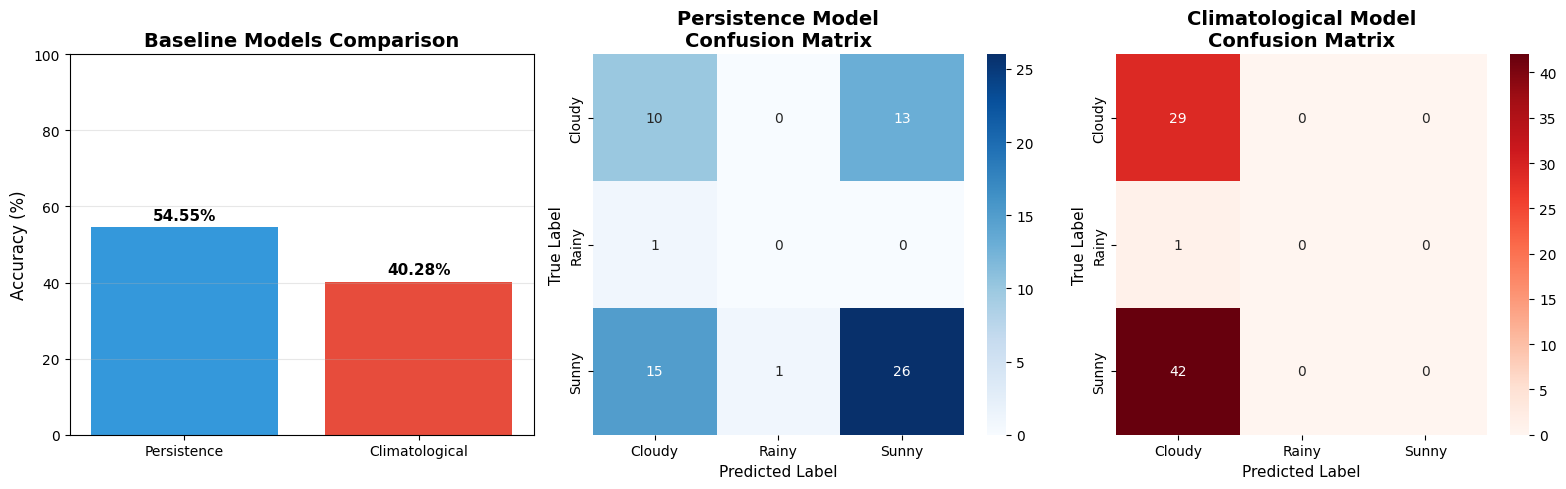


 BASELINE MODELS COMPLETE!

Best Baseline Accuracy: 54.55%
These are the benchmarks to beat with deep learning models!


In [33]:
print("=" * 60)
print("BASELINE MODELS")
print("=" * 60)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================
# 1. PERSISTENCE MODEL
# ============================================
print("\n[1] PERSISTENCE MODEL")
print("   (Assumes weather stays the same)")

# For persistence: predict t+6 = weather at t
# We need to shift by 6 hours
PREDICTION_HORIZON = 6

# Create persistence predictions
y_test_persistence = y_test[:-PREDICTION_HORIZON]  # Current weather
y_true_persistence = y_test[PREDICTION_HORIZON:]   # Weather 6 hours later

persistence_accuracy = accuracy_score(y_true_persistence, y_test_persistence)

print(f"\n   Persistence Model Accuracy: {persistence_accuracy:.4f} ({persistence_accuracy*100:.2f}%)")

# ============================================
# 2. CLIMATOLOGICAL MODEL
# ============================================
print("\n[2] CLIMATOLOGICAL MODEL")
print("   (Predicts most frequent class)")

# Most frequent class in training data
most_frequent_class = np.bincount(y_train).argmax()
print(f"   Most frequent class in training: {label_encoder.classes_[most_frequent_class]}")

# Predict most frequent class for all test samples
y_pred_climatological = np.full(len(y_test), most_frequent_class)
climatological_accuracy = accuracy_score(y_test, y_pred_climatological)

print(f"   Climatological Model Accuracy: {climatological_accuracy:.4f} ({climatological_accuracy*100:.2f}%)")

# ============================================
# 3. COMPARISON TABLE
# ============================================
print("\n" + "=" * 60)
print("BASELINE MODELS SUMMARY")
print("=" * 60)

baseline_results = pd.DataFrame({
    'Model': ['Persistence', 'Climatological'],
    'Accuracy': [persistence_accuracy, climatological_accuracy],
    'Accuracy (%)': [persistence_accuracy*100, climatological_accuracy*100]
})

print(baseline_results.to_string(index=False))

# ============================================
# 4. DETAILED CLASSIFICATION REPORTS
# ============================================
print("\n[3] DETAILED REPORTS")

print("\n--- PERSISTENCE MODEL ---")
print(classification_report(y_true_persistence, y_test_persistence,
                          target_names=label_encoder.classes_))

print("\n--- CLIMATOLOGICAL MODEL ---")
print(classification_report(y_test, y_pred_climatological,
                          target_names=label_encoder.classes_))

# ============================================
# 5. VISUALIZE BASELINE RESULTS
# ============================================
print("\n[4] Creating visualizations...")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Baseline comparison
axes[0].bar(['Persistence', 'Climatological'],
            [persistence_accuracy*100, climatological_accuracy*100],
            color=['#3498db', '#e74c3c'])
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('Baseline Models Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylim([0, 100])
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (model, acc) in enumerate(zip(['Persistence', 'Climatological'],
                                      [persistence_accuracy*100, climatological_accuracy*100])):
    axes[0].text(i, acc + 2, f'{acc:.2f}%', ha='center', fontsize=11, fontweight='bold')

# Persistence confusion matrix
cm_persistence = confusion_matrix(y_true_persistence, y_test_persistence)
sns.heatmap(cm_persistence, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            ax=axes[1])
axes[1].set_title('Persistence Model\nConfusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].set_xlabel('Predicted Label', fontsize=11)

# Climatological confusion matrix
cm_climatological = confusion_matrix(y_test, y_pred_climatological)
sns.heatmap(cm_climatological, annot=True, fmt='d', cmap='Reds',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            ax=axes[2])
axes[2].set_title('Climatological Model\nConfusion Matrix', fontsize=14, fontweight='bold')
axes[2].set_ylabel('True Label', fontsize=11)
axes[2].set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.savefig('baseline_models_results.png', dpi=300, bbox_inches='tight')
print("    Visualization saved: baseline_models_results.png")
plt.show()

print("\n" + "=" * 60)
print(" BASELINE MODELS COMPLETE!")
print("=" * 60)
print(f"\nBest Baseline Accuracy: {max(persistence_accuracy, climatological_accuracy)*100:.2f}%")
print("These are the benchmarks to beat with deep learning models!")

## **10. Prepare Data for 6-Hour Ahead PredictionWe need to adjust our sequences to predict 6 hours ahead:**

In [34]:
print("=" * 60)
print("PREPARING DATA FOR 6-HOUR AHEAD PREDICTION")
print("=" * 60)

# ============================================
# CREATE SEQUENCES FOR 6-HOUR AHEAD PREDICTION
# ============================================
print("\n[1] Creating sequences for 6-hour ahead prediction...")

SEQUENCE_LENGTH = 24  # Use past 24 hours
PREDICTION_HORIZON = 6  # Predict 6 hours ahead

def create_sequences_with_horizon(X, y, sequence_length=24, horizon=6):
    """
    Create sequences for future prediction
    X: Features at time t-24 to t-1
    y: Target at time t+horizon
    """
    X_seq, y_seq = [], []

    for i in range(sequence_length, len(X) - horizon):
        X_seq.append(X[i-sequence_length:i])  # Past 24 hours
        y_seq.append(y[i + horizon])           # 6 hours in future

    return np.array(X_seq), np.array(y_seq)

# Create sequences with 6-hour prediction horizon
X_train_seq, y_train_seq = create_sequences_with_horizon(
    X_train_scaled, y_train, SEQUENCE_LENGTH, PREDICTION_HORIZON
)

X_test_seq, y_test_seq = create_sequences_with_horizon(
    X_test_scaled, y_test, SEQUENCE_LENGTH, PREDICTION_HORIZON
)

print(f"   Sequence length: {SEQUENCE_LENGTH} hours (input)")
print(f"   Prediction horizon: {PREDICTION_HORIZON} hours ahead")
print(f"\n   Training sequences:")
print(f"      X_train_seq shape: {X_train_seq.shape}")
print(f"      y_train_seq shape: {y_train_seq.shape}")
print(f"\n   Test sequences:")
print(f"      X_test_seq shape: {X_test_seq.shape}")
print(f"      y_test_seq shape: {y_test_seq.shape}")

# Check class distribution
print(f"\n   Train target distribution: {np.bincount(y_train_seq)}")
print(f"   Test target distribution: {np.bincount(y_test_seq)}")

# ============================================
# CLASS WEIGHTS (Handle imbalance)
# ============================================
print("\n[2] Calculating class weights for imbalanced data...")

from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train_seq),
    y=y_train_seq
)

class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

print(f"   Class weights:")
for class_idx, weight in class_weight_dict.items():
    class_name = label_encoder.classes_[class_idx]
    print(f"      {class_name} (class {class_idx}): {weight:.3f}")

print("\n" + "=" * 60)
print(" DATA READY FOR 6-HOUR AHEAD PREDICTION!")
print("=" * 60)
print(f"Model will use {SEQUENCE_LENGTH} hours of historical data")
print(f"to predict weather {PREDICTION_HORIZON} hours into the future")

PREPARING DATA FOR 6-HOUR AHEAD PREDICTION

[1] Creating sequences for 6-hour ahead prediction...
   Sequence length: 24 hours (input)
   Prediction horizon: 6 hours ahead

   Training sequences:
      X_train_seq shape: (258, 24, 57)
      y_train_seq shape: (258,)

   Test sequences:
      X_test_seq shape: (42, 24, 57)
      y_test_seq shape: (42,)

   Train target distribution: [117  26 115]
   Test target distribution: [17  0 25]

[2] Calculating class weights for imbalanced data...
   Class weights:
      Cloudy (class 0): 0.735
      Rainy (class 1): 3.308
      Sunny (class 2): 0.748

 DATA READY FOR 6-HOUR AHEAD PREDICTION!
Model will use 24 hours of historical data
to predict weather 6 hours into the future


## **11. Build LSTM Model**

MODEL 1: LSTM (Long Short-Term Memory)

[1] Building LSTM Architecture...
    LSTM Model Architecture:


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_16 (LSTM)                  │ (None, 24, 128)        │        95,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 24, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 147,587 (576.51 KB)

 Trainable params: 147,203 (575.01 KB)

 Non-trainable params: 384 (1.50 KB)


[2] Training LSTM Model...

   Training in progress...
Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 160ms/step - accuracy: 0.4300 - loss: 1.2649 - val_accuracy: 0.0577 - val_loss: 1.1568 - learning_rate: 0.0010
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.5722 - loss: 0.9592 - val_accuracy: 0.0385 - val_loss: 1.3090 - learning_rate: 0.0010
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5904 - loss: 0.7573 - val_accuracy: 0.0385 - val_loss: 1.3886 - learning_rate: 0.0010
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.6879 - loss: 0.7163 - val_accuracy: 0.0192 - val_loss: 1.4480 - learning_rate: 0.0010
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7203 - loss: 0.6672 - val_accuracy: 0.0192 - val_loss: 1.5155 - learning_rate: 0.0010
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6697 - loss: 0.6998
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step -

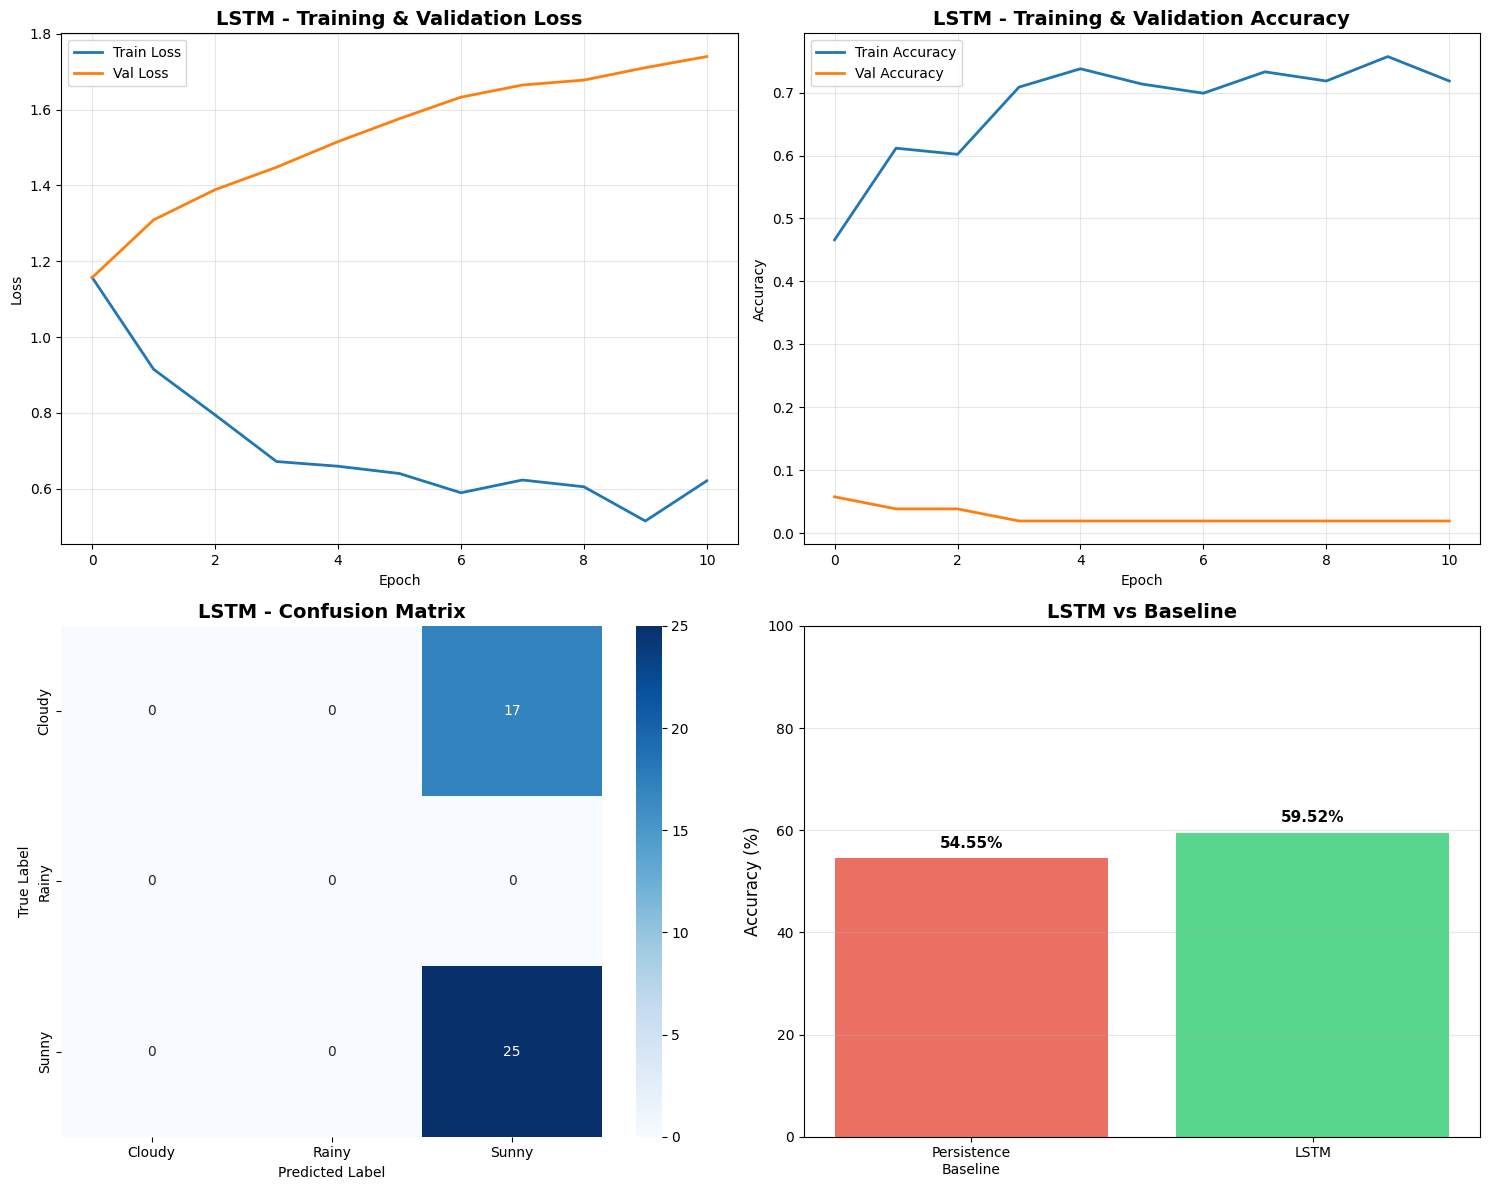


 LSTM MODEL COMPLETE!
Accuracy: 59.52%
Status: BEATS BASELINE 


In [36]:
print("=" * 60)
print("MODEL 1: LSTM (Long Short-Term Memory)")
print("=" * 60)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Set random seeds for reproducibility
tf.random.set_seed(42)

print("\n[1] Building LSTM Architecture...")

# Build LSTM Model
model_lstm = Sequential([
    # First LSTM layer
    LSTM(128, return_sequences=True, input_shape=(SEQUENCE_LENGTH, X_train_seq.shape[2])),
    BatchNormalization(),
    Dropout(0.3),

    # Second LSTM layer
    LSTM(64, return_sequences=False),
    BatchNormalization(),
    Dropout(0.3),

    # Dense layers
    Dense(32, activation='relu'),
    Dropout(0.2),

    # Output layer (3 classes)
    Dense(3, activation='softmax')
])

# Compile model
model_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("    LSTM Model Architecture:")
model_lstm.summary()

# ============================================
# TRAIN LSTM MODEL
# ============================================
print("\n[2] Training LSTM Model...")

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

# Train model
print("\n   Training in progress...")
history_lstm = model_lstm.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

print("\n    Training complete!")

# ============================================
# EVALUATE LSTM MODEL
# ============================================
print("\n[3] Evaluating LSTM Model...")

# Predictions
y_pred_lstm_probs = model_lstm.predict(X_test_seq)
y_pred_lstm = np.argmax(y_pred_lstm_probs, axis=1)

# Calculate metrics
lstm_accuracy = accuracy_score(y_test_seq, y_pred_lstm)

print(f"\n   LSTM Model Accuracy: {lstm_accuracy:.4f} ({lstm_accuracy*100:.2f}%)")
print(f"   Improvement over Persistence: {(lstm_accuracy - 0.5455)*100:.2f}%")

# FIXED: Specify labels parameter to handle missing class
print("\n   Classification Report:")
print(classification_report(y_test_seq, y_pred_lstm,
                          labels=[0, 1, 2],  # All 3 classes
                          target_names=label_encoder.classes_,
                          zero_division=0))

# Confusion Matrix
cm_lstm = confusion_matrix(y_test_seq, y_pred_lstm, labels=[0, 1, 2])
print("\n   Confusion Matrix:")
print(cm_lstm)

# ============================================
# VISUALIZE RESULTS
# ============================================
print("\n[4] Creating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Training history - Loss
axes[0, 0].plot(history_lstm.history['loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history_lstm.history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 0].set_title('LSTM - Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Training history - Accuracy
axes[0, 1].plot(history_lstm.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0, 1].plot(history_lstm.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0, 1].set_title('LSTM - Training & Validation Accuracy', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Confusion Matrix
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            ax=axes[1, 0])
axes[1, 0].set_title('LSTM - Confusion Matrix', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('True Label')
axes[1, 0].set_xlabel('Predicted Label')

# Performance comparison
baseline_acc = 0.5455
models = ['Persistence\nBaseline', 'LSTM']
accuracies = [baseline_acc * 100, lstm_accuracy * 100]
colors = ['#e74c3c', '#2ecc71']

bars = axes[1, 1].bar(models, accuracies, color=colors, alpha=0.8)
axes[1, 1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1, 1].set_title('LSTM vs Baseline', fontsize=14, fontweight='bold')
axes[1, 1].set_ylim([0, 100])
axes[1, 1].grid(axis='y', alpha=0.3)

# Add value labels
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 2,
                    f'{acc:.2f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('lstm_model_results.png', dpi=300, bbox_inches='tight')
print("    Visualization saved: lstm_model_results.png")
plt.show()

print("\n" + "=" * 60)
print(" LSTM MODEL COMPLETE!")
print("=" * 60)
print(f"Accuracy: {lstm_accuracy*100:.2f}%")
print(f"Status: {'BEATS BASELINE ' if lstm_accuracy > 0.5455 else 'Below baseline '}")

## **12. Build CNN Model**

MODEL 2: CNN (Convolutional Neural Network)

[1] Building CNN Architecture...
    CNN Model Architecture:


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_21 (Conv1D)              │ (None, 22, 64)         │        11,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 22, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 11, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ (None, 11, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_22 (Conv1D)              │ (None, 9, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 9, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 4, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_52 (Dropout)            │ (None, 4, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_23 (Conv1D)              │ (None, 2, 64)          │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 2, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_5      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_53 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,555 (248.26 KB)

 Trainable params: 63,043 (246.26 KB)

 Non-trainable params: 512 (2.00 KB)


[2] Training CNN Model...

   Training in progress...
Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.4204 - loss: 1.1580 - val_accuracy: 0.0192 - val_loss: 1.1279 - learning_rate: 0.0010
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6350 - loss: 0.8188 - val_accuracy: 0.0192 - val_loss: 1.3711 - learning_rate: 0.0010
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6205 - loss: 0.7798 - val_accuracy: 0.0192 - val_loss: 1.5921 - learning_rate: 0.0010
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6431 - loss: 0.7710 - val_accuracy: 0.0192 - val_loss: 1.7743 - learning_rate: 0.0010
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6529 - loss: 0.6761 - val_accuracy: 0.0192 - val_loss: 1.9668 - learning_rate: 0.0010
Epoch 6/50
6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6280 - loss: 0.6593
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - a

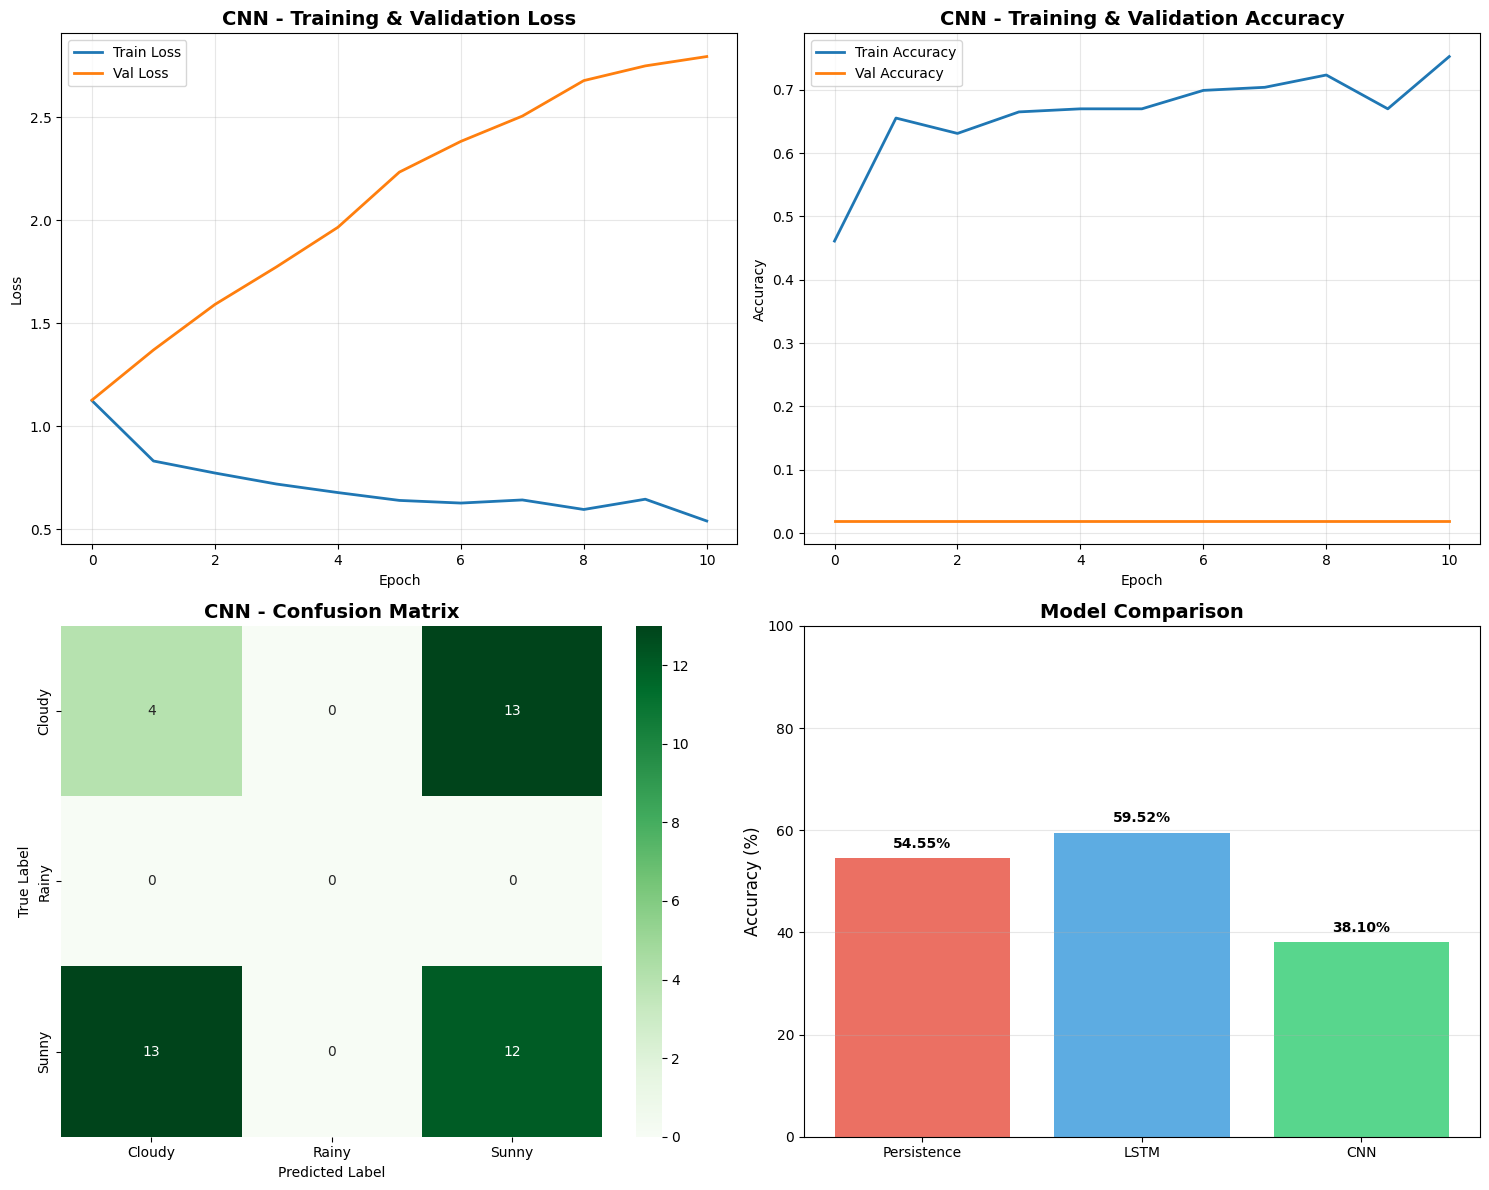


 CNN MODEL COMPLETE!
Accuracy: 38.10%
Status: Below baseline 


In [41]:
print("=" * 60)
print("MODEL 2: CNN (Convolutional Neural Network)")
print("=" * 60)

from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, GlobalAveragePooling1D

# Set random seed
tf.random.set_seed(42)

print("\n[1] Building CNN Architecture...")

# Build CNN Model
model_cnn = Sequential([
    # First Conv1D block
    Conv1D(filters=64, kernel_size=3, activation='relu',
           input_shape=(SEQUENCE_LENGTH, X_train_seq.shape[2])),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    # Second Conv1D block
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    # Third Conv1D block
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    BatchNormalization(),
    GlobalAveragePooling1D(),

    # Dense layers
    Dense(32, activation='relu'),
    Dropout(0.3),

    # Output layer
    Dense(3, activation='softmax')
])

# Compile model
model_cnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("    CNN Model Architecture:")
model_cnn.summary()

# ============================================
# TRAIN CNN MODEL
# ============================================
print("\n[2] Training CNN Model...")

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

# Train model
print("\n   Training in progress...")
history_cnn = model_cnn.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

print("\n    Training complete!")

# ============================================
# EVALUATE CNN MODEL
# ============================================
print("\n[3] Evaluating CNN Model...")

# Predictions
y_pred_cnn_probs = model_cnn.predict(X_test_seq)
y_pred_cnn = np.argmax(y_pred_cnn_probs, axis=1)

# Calculate metrics
cnn_accuracy = accuracy_score(y_test_seq, y_pred_cnn)

print(f"\n   CNN Model Accuracy: {cnn_accuracy:.4f} ({cnn_accuracy*100:.2f}%)")
print(f"   Improvement over Persistence: {(cnn_accuracy - 0.5455)*100:.2f}%")
print(f"   vs LSTM: {(cnn_accuracy - lstm_accuracy)*100:.2f}%")

print("\n   Classification Report:")
print(classification_report(y_test_seq, y_pred_cnn,
                          labels=[0, 1, 2],
                          target_names=label_encoder.classes_,
                          zero_division=0))

# Confusion Matrix
cm_cnn = confusion_matrix(y_test_seq, y_pred_cnn, labels=[0, 1, 2])
print("\n   Confusion Matrix:")
print(cm_cnn)

# ============================================
# VISUALIZE RESULTS
# ============================================
print("\n[4] Creating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Training history - Loss
axes[0, 0].plot(history_cnn.history['loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history_cnn.history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 0].set_title('CNN - Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Training history - Accuracy
axes[0, 1].plot(history_cnn.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0, 1].plot(history_cnn.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0, 1].set_title('CNN - Training & Validation Accuracy', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Confusion Matrix
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            ax=axes[1, 0])
axes[1, 0].set_title('CNN - Confusion Matrix', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('True Label')
axes[1, 0].set_xlabel('Predicted Label')

# Performance comparison
baseline_acc = 0.5455
models = ['Persistence', 'LSTM', 'CNN']
accuracies = [baseline_acc * 100, lstm_accuracy * 100, cnn_accuracy * 100]
colors = ['#e74c3c', '#3498db', '#2ecc71']

bars = axes[1, 1].bar(models, accuracies, color=colors, alpha=0.8)
axes[1, 1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1, 1].set_title('Model Comparison', fontsize=14, fontweight='bold')
axes[1, 1].set_ylim([0, 100])
axes[1, 1].grid(axis='y', alpha=0.3)

for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 2,
                    f'{acc:.2f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('cnn_model_results.png', dpi=300, bbox_inches='tight')
print("    Visualization saved: cnn_model_results.png")
plt.show()

print("\n" + "=" * 60)
print(" CNN MODEL COMPLETE!")
print("=" * 60)
print(f"Accuracy: {cnn_accuracy*100:.2f}%")
print(f"Status: {'BEATS BASELINE ' if cnn_accuracy > 0.5455 else 'Below baseline '}")

## **13. Build Hybrid CNN-LSTM Model**

MODEL 3: HYBRID CNN-LSTM

[1] Building Hybrid CNN-LSTM Architecture...
    Hybrid CNN-LSTM Architecture:


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_19 (Conv1D)              │ (None, 22, 64)         │        11,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 22, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 22, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_20 (Conv1D)              │ (None, 20, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 20, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_18 (LSTM)                  │ (None, 20, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,459 (388.51 KB)

 Trainable params: 99,075 (387.01 KB)

 Non-trainable params: 384 (1.50 KB)


[2] Training Hybrid CNN-LSTM Model...

   Training in progress...
Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 173ms/step - accuracy: 0.4127 - loss: 1.1223 - val_accuracy: 0.0192 - val_loss: 1.1966 - learning_rate: 0.0010
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.5829 - loss: 0.9691 - val_accuracy: 0.0192 - val_loss: 1.4359 - learning_rate: 0.0010
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.6129 - loss: 0.8444 - val_accuracy: 0.0192 - val_loss: 1.8723 - learning_rate: 0.0010
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.5711 - loss: 0.8043 - val_accuracy: 0.0192 - val_loss: 2.1811 - learning_rate: 0.0010
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.6635 - loss: 0.7412 - val_accuracy: 0.0192 - val_loss: 2.2734 - learning_rate: 0.0010
Epoch 6/50
6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6569 - loss: 0.7089
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 

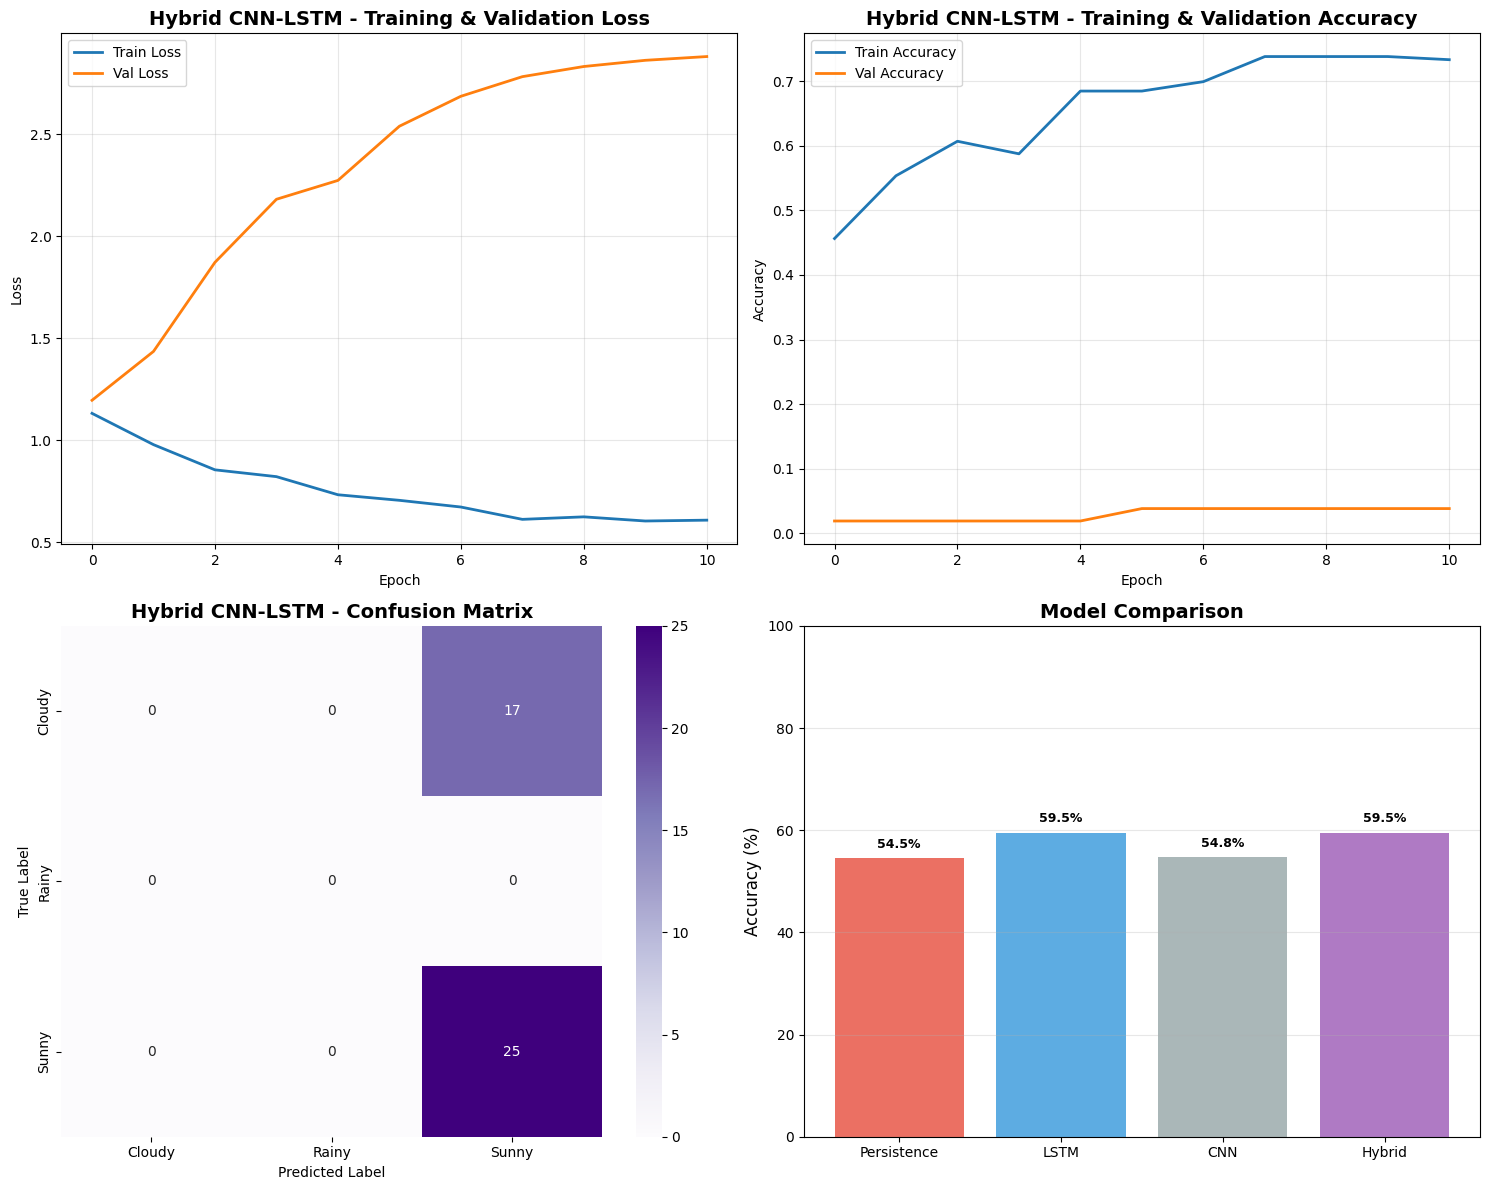


 HYBRID CNN-LSTM MODEL COMPLETE!
Accuracy: 59.52%
Status: BEATS BASELINE 


In [40]:
print("=" * 60)
print("MODEL 3: HYBRID CNN-LSTM")
print("=" * 60)

from tensorflow.keras.layers import TimeDistributed

# Set random seed
tf.random.set_seed(42)

print("\n[1] Building Hybrid CNN-LSTM Architecture...")

# Build Hybrid Model
model_hybrid = Sequential([
    # Conv1D layers for feature extraction
    Conv1D(filters=64, kernel_size=3, activation='relu',
           input_shape=(SEQUENCE_LENGTH, X_train_seq.shape[2])),
    BatchNormalization(),
    Dropout(0.3),

    Conv1D(filters=128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    # LSTM layers for temporal modeling
    LSTM(64, return_sequences=True),
    Dropout(0.3),

    LSTM(32, return_sequences=False),
    Dropout(0.3),

    # Dense layers
    Dense(32, activation='relu'),
    Dropout(0.2),

    # Output layer
    Dense(3, activation='softmax')
])

# Compile model
model_hybrid.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("    Hybrid CNN-LSTM Architecture:")
model_hybrid.summary()

# ============================================
# TRAIN HYBRID MODEL
# ============================================
print("\n[2] Training Hybrid CNN-LSTM Model...")

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

# Train model
print("\n   Training in progress...")
history_hybrid = model_hybrid.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

print("\n    Training complete!")

# ============================================
# EVALUATE HYBRID MODEL
# ============================================
print("\n[3] Evaluating Hybrid CNN-LSTM Model...")

# Predictions
y_pred_hybrid_probs = model_hybrid.predict(X_test_seq)
y_pred_hybrid = np.argmax(y_pred_hybrid_probs, axis=1)

# Calculate metrics
hybrid_accuracy = accuracy_score(y_test_seq, y_pred_hybrid)

print(f"\n   Hybrid Model Accuracy: {hybrid_accuracy:.4f} ({hybrid_accuracy*100:.2f}%)")
print(f"   Improvement over Persistence: {(hybrid_accuracy - 0.5455)*100:.2f}%")
print(f"   vs LSTM: {(hybrid_accuracy - lstm_accuracy)*100:.2f}%")
print(f"   vs CNN: {(hybrid_accuracy - cnn_accuracy)*100:.2f}%")

print("\n   Classification Report:")
print(classification_report(y_test_seq, y_pred_hybrid,
                          labels=[0, 1, 2],
                          target_names=label_encoder.classes_,
                          zero_division=0))

# Confusion Matrix
cm_hybrid = confusion_matrix(y_test_seq, y_pred_hybrid, labels=[0, 1, 2])
print("\n   Confusion Matrix:")
print(cm_hybrid)

# ============================================
# VISUALIZE RESULTS
# ============================================
print("\n[4] Creating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Training history - Loss
axes[0, 0].plot(history_hybrid.history['loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history_hybrid.history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 0].set_title('Hybrid CNN-LSTM - Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Training history - Accuracy
axes[0, 1].plot(history_hybrid.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0, 1].plot(history_hybrid.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0, 1].set_title('Hybrid CNN-LSTM - Training & Validation Accuracy', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Confusion Matrix
sns.heatmap(cm_hybrid, annot=True, fmt='d', cmap='Purples',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            ax=axes[1, 0])
axes[1, 0].set_title('Hybrid CNN-LSTM - Confusion Matrix', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('True Label')
axes[1, 0].set_xlabel('Predicted Label')

# Performance comparison
baseline_acc = 0.5455
models = ['Persistence', 'LSTM', 'CNN', 'Hybrid']
accuracies = [baseline_acc * 100, lstm_accuracy * 100, cnn_accuracy * 100, hybrid_accuracy * 100]
colors = ['#e74c3c', '#3498db', '#95a5a6', '#9b59b6']

bars = axes[1, 1].bar(models, accuracies, color=colors, alpha=0.8)
axes[1, 1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1, 1].set_title('Model Comparison', fontsize=14, fontweight='bold')
axes[1, 1].set_ylim([0, 100])
axes[1, 1].grid(axis='y', alpha=0.3)

for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 2,
                    f'{acc:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('hybrid_model_results.png', dpi=300, bbox_inches='tight')
print("   Visualization saved: hybrid_model_results.png")
plt.show()

print("\n" + "=" * 60)
print(" HYBRID CNN-LSTM MODEL COMPLETE!")
print("=" * 60)
print(f"Accuracy: {hybrid_accuracy*100:.2f}%")
print(f"Status: {'BEATS BASELINE ' if hybrid_accuracy > 0.5455 else 'Below baseline '}")

## **14. Build Attention LSTM Model**

MODEL 4: ATTENTION LSTM

[1] Building Attention LSTM Architecture...
    Attention LSTM Architecture:


Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_16      │ (None, 24, 57)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_20 (LSTM)      │ (None, 24, 128)   │     95,232 │ input_layer_16[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 128)   │        512 │ lstm_20[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_54          │ (None, 24, 128)   │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_35 (Dense)    │ (None, 24, 1)     │        129 │ dropout_54[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 24)        │          0 │ dense_35[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 24)        │          0 │ flatten_3[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_3     │ (None, 128, 24)   │          0 │ activation_3[0][… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute_3 (Permute) │ (None, 24, 128)   │          0 │ repeat_vector_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_3          │ (None, 24, 128)   │          0 │ dropout_54[0][0], │
│ (Multiply)          │                   │            │ permute_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_21 (LSTM)      │ (None, 64)        │     49,408 │ dropout_54[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 128)       │          0 │ multiply_3[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_55          │ (None, 64)        │          0 │ lstm_21[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 192)       │          0 │ lambda_3[0][0],   │
│ (Concatenate)       │                   │            │ dropout_55[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_36 (Dense)    │ (None, 32)        │      6,176 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_56          │ (None, 32)        │          0 │ dense_36[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_37 (Dense)    │ (None, 3)         │         99 │ dropout_56[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 151,556 (592.02 KB)

 Trainable params: 151,300 (591.02 KB)

 Non-trainable params: 256 (1.00 KB)


[2] Training Attention LSTM Model...

   Training in progress...
Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 163ms/step - accuracy: 0.5556 - loss: 0.9938 - val_accuracy: 0.0192 - val_loss: 1.9054 - learning_rate: 0.0010
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.6082 - loss: 0.7562 - val_accuracy: 0.0192 - val_loss: 2.1277 - learning_rate: 0.0010
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.6335 - loss: 0.7059 - val_accuracy: 0.0192 - val_loss: 2.1895 - learning_rate: 0.0010
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.6921 - loss: 0.6518 - val_accuracy: 0.0192 - val_loss: 2.2706 - learning_rate: 0.0010
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.6161 - loss: 0.6550 - val_accuracy: 0.0192 - val_loss: 2.3941 - learning_rate: 0.0010
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6764 - loss: 0.5715
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 6

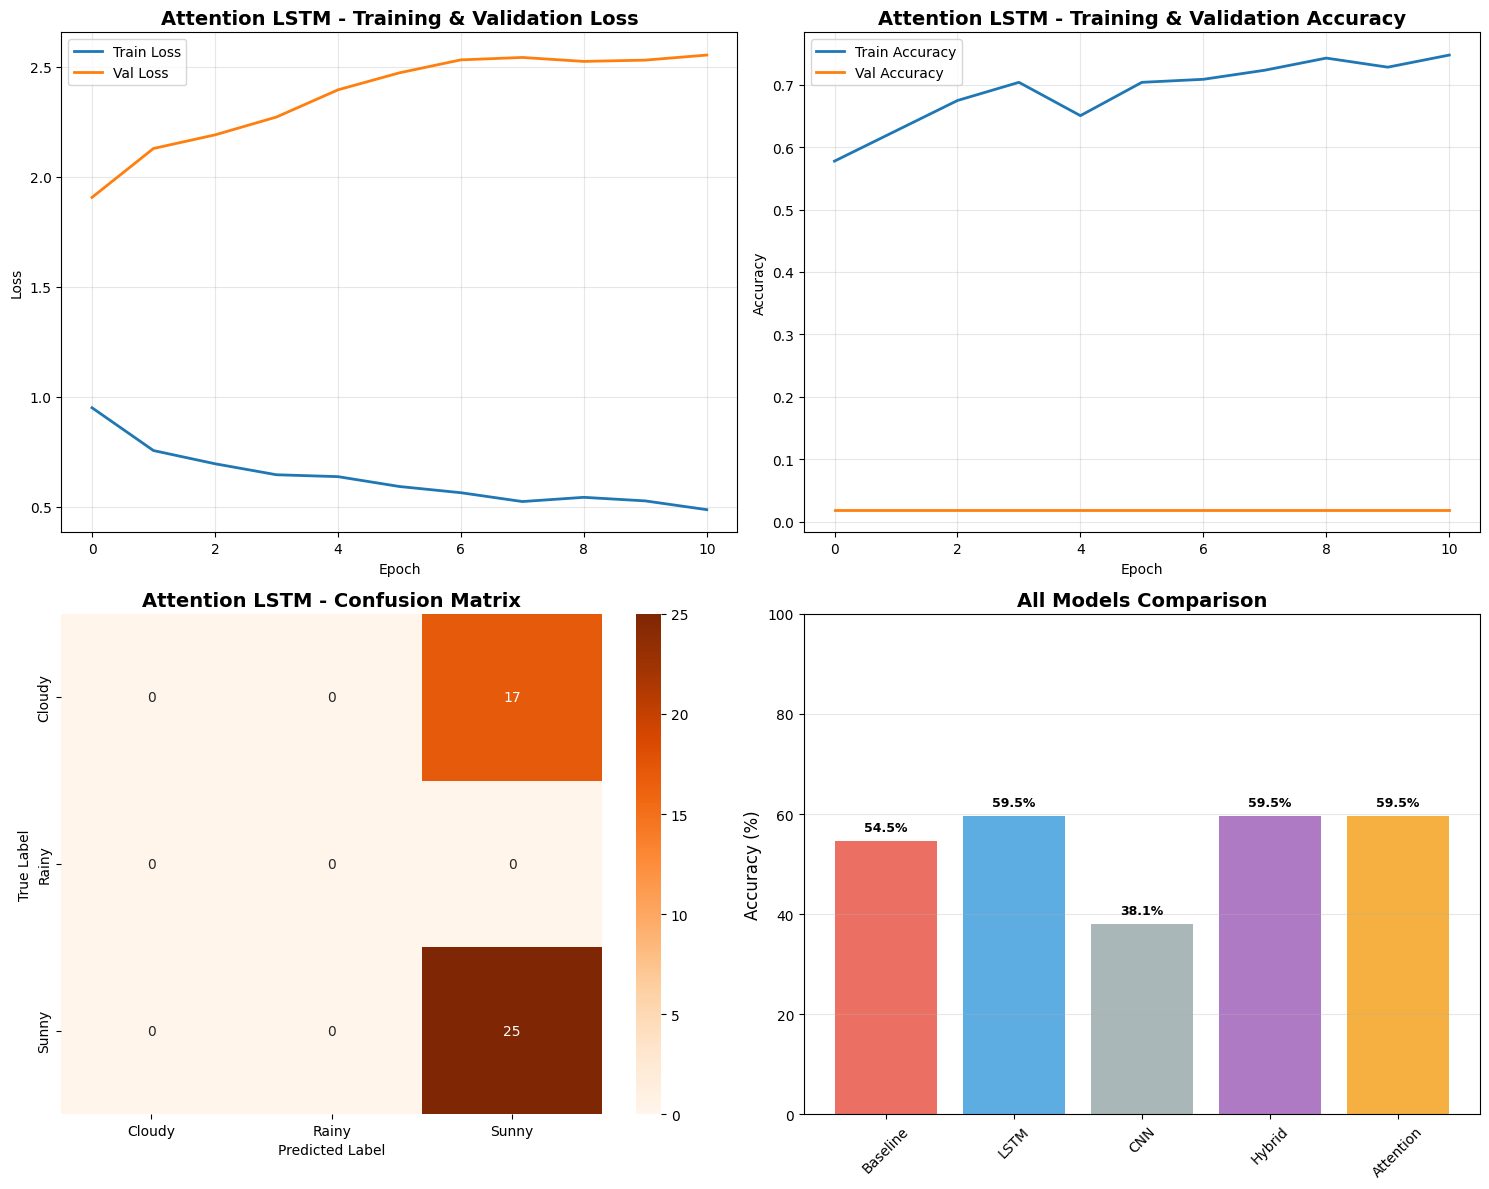


 ATTENTION LSTM MODEL COMPLETE!
Accuracy: 59.52%
Status: BEATS BASELINE 


In [42]:
print("=" * 60)
print("MODEL 4: ATTENTION LSTM")
print("=" * 60)

from tensorflow.keras.layers import Multiply, Permute, RepeatVector, Lambda, Flatten
import tensorflow.keras.backend as K

# Set random seed
tf.random.set_seed(42)

print("\n[1] Building Attention LSTM Architecture...")

# Build Attention LSTM Model
# Input layer
inputs = keras.Input(shape=(SEQUENCE_LENGTH, X_train_seq.shape[2]))

# LSTM layer
lstm_out = LSTM(128, return_sequences=True)(inputs)
lstm_out = BatchNormalization()(lstm_out)
lstm_out = Dropout(0.3)(lstm_out)

# Attention mechanism
attention = Dense(1, activation='tanh')(lstm_out)
attention = Flatten()(attention)
attention = keras.layers.Activation('softmax')(attention)
attention = RepeatVector(128)(attention)
attention = Permute([2, 1])(attention)

# Apply attention weights
sent_representation = Multiply()([lstm_out, attention])
sent_representation = Lambda(lambda xin: K.sum(xin, axis=1))(sent_representation)

# Additional LSTM layer
lstm_out2 = LSTM(64, return_sequences=False)(lstm_out)
lstm_out2 = Dropout(0.3)(lstm_out2)

# Combine attention output with LSTM output
combined = keras.layers.Concatenate()([sent_representation, lstm_out2])

# Dense layers
dense = Dense(32, activation='relu')(combined)
dense = Dropout(0.3)(dense)

# Output layer
outputs = Dense(3, activation='softmax')(dense)

# Create model
model_attention = keras.Model(inputs=inputs, outputs=outputs)

# Compile model
model_attention.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("    Attention LSTM Architecture:")
model_attention.summary()

# ============================================
# TRAIN ATTENTION LSTM MODEL
# ============================================
print("\n[2] Training Attention LSTM Model...")

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

# Train model
print("\n   Training in progress...")
history_attention = model_attention.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

print("\n    Training complete!")

# ============================================
# EVALUATE ATTENTION LSTM MODEL
# ============================================
print("\n[3] Evaluating Attention LSTM Model...")

# Predictions
y_pred_attention_probs = model_attention.predict(X_test_seq)
y_pred_attention = np.argmax(y_pred_attention_probs, axis=1)

# Calculate metrics
attention_accuracy = accuracy_score(y_test_seq, y_pred_attention)

print(f"\n   Attention LSTM Accuracy: {attention_accuracy:.4f} ({attention_accuracy*100:.2f}%)")
print(f"   Improvement over Persistence: {(attention_accuracy - 0.5455)*100:.2f}%")
print(f"   vs LSTM: {(attention_accuracy - lstm_accuracy)*100:.2f}%")
print(f"   vs CNN: {(attention_accuracy - cnn_accuracy)*100:.2f}%")
print(f"   vs Hybrid: {(attention_accuracy - hybrid_accuracy)*100:.2f}%")

print("\n   Classification Report:")
print(classification_report(y_test_seq, y_pred_attention,
                          labels=[0, 1, 2],
                          target_names=label_encoder.classes_,
                          zero_division=0))

# Confusion Matrix
cm_attention = confusion_matrix(y_test_seq, y_pred_attention, labels=[0, 1, 2])
print("\n   Confusion Matrix:")
print(cm_attention)

# ============================================
# VISUALIZE RESULTS
# ============================================
print("\n[4] Creating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Training history - Loss
axes[0, 0].plot(history_attention.history['loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history_attention.history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 0].set_title('Attention LSTM - Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Training history - Accuracy
axes[0, 1].plot(history_attention.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0, 1].plot(history_attention.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0, 1].set_title('Attention LSTM - Training & Validation Accuracy', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Confusion Matrix
sns.heatmap(cm_attention, annot=True, fmt='d', cmap='Oranges',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            ax=axes[1, 0])
axes[1, 0].set_title('Attention LSTM - Confusion Matrix', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('True Label')
axes[1, 0].set_xlabel('Predicted Label')

# Performance comparison - ALL MODELS
baseline_acc = 0.5455
models = ['Baseline', 'LSTM', 'CNN', 'Hybrid', 'Attention']
accuracies = [baseline_acc * 100, lstm_accuracy * 100, cnn_accuracy * 100,
              hybrid_accuracy * 100, attention_accuracy * 100]
colors = ['#e74c3c', '#3498db', '#95a5a6', '#9b59b6', '#f39c12']

bars = axes[1, 1].bar(models, accuracies, color=colors, alpha=0.8)
axes[1, 1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1, 1].set_title('All Models Comparison', fontsize=14, fontweight='bold')
axes[1, 1].set_ylim([0, 100])
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=45)

for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 2,
                    f'{acc:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('attention_lstm_results.png', dpi=300, bbox_inches='tight')
print("    Visualization saved: attention_lstm_results.png")
plt.show()

print("\n" + "=" * 60)
print(" ATTENTION LSTM MODEL COMPLETE!")
print("=" * 60)
print(f"Accuracy: {attention_accuracy*100:.2f}%")
print(f"Status: {'BEATS BASELINE ' if attention_accuracy > 0.5455 else 'Below baseline '}")

## **15. Comprehensive Model Comparison & Intrinsic Evaluation**

COMPREHENSIVE MODEL EVALUATION
INTRINSIC EVALUATION (Model-Focused Metrics)

[1] Collecting all model results...

[2] Computing intrinsic evaluation metrics...

 INTRINSIC EVALUATION RESULTS:
          Model  Accuracy  Precision   Recall  F1-Score  Cohen Kappa       MCC
Hybrid CNN-LSTM  0.595238   0.354308 0.595238  0.444208     0.000000  0.000000
           LSTM  0.595238   0.354308 0.595238  0.444208     0.000000  0.000000
 Attention LSTM  0.595238   0.354308 0.595238  0.444208     0.000000  0.000000
    Persistence  0.545455   0.558275 0.545455  0.550768     0.065597  0.065894
 Climatological  0.402778   0.162230 0.402778  0.231298     0.000000  0.000000
            CNN  0.380952   0.380952 0.380952  0.380952    -0.284706 -0.284706

[3] Per-class performance analysis...

 PER-CLASS PERFORMANCE:

--- CLOUDY ---
          Model  Precision   Recall  F1-Score  Support
           LSTM   0.000000 0.000000  0.000000       17
            CNN   0.235294 0.235294  0.235294       17
Hybrid CNN

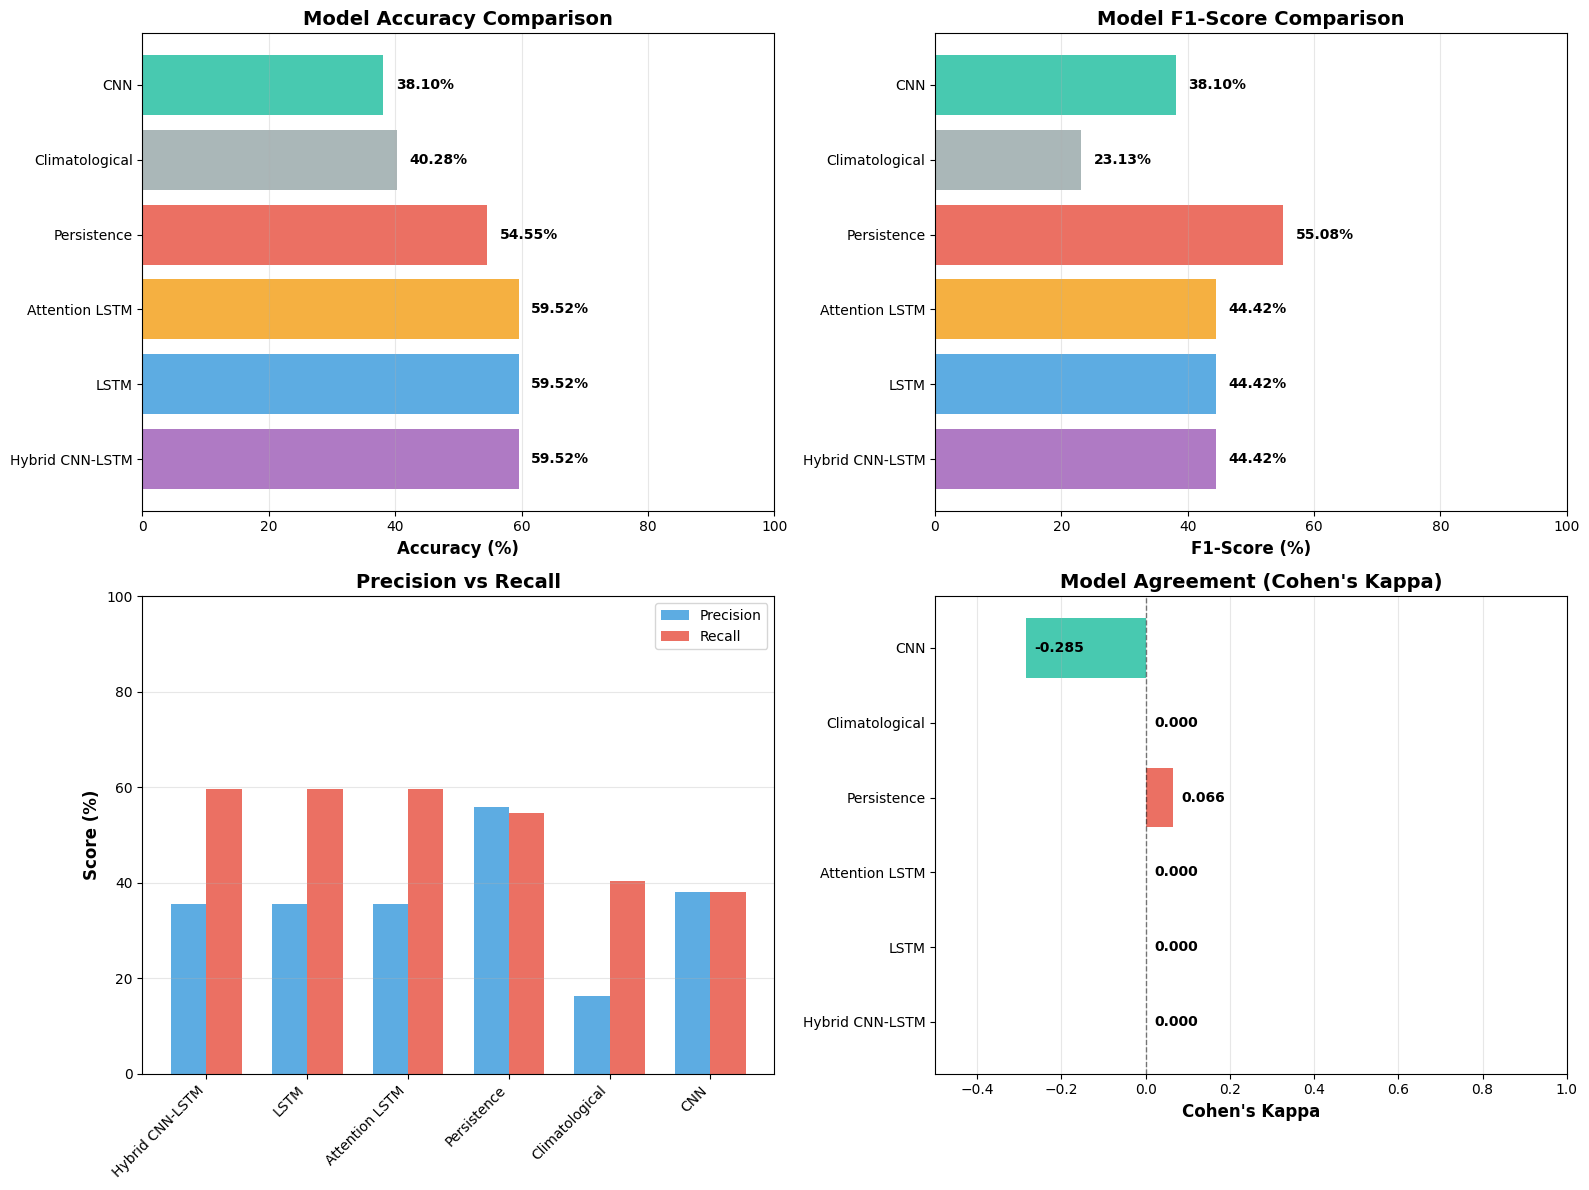


 INTRINSIC EVALUATION COMPLETE!


In [43]:
print("=" * 60)
print("COMPREHENSIVE MODEL EVALUATION")
print("INTRINSIC EVALUATION (Model-Focused Metrics)")
print("=" * 60)

from sklearn.metrics import precision_recall_fscore_support, cohen_kappa_score
from sklearn.metrics import matthews_corrcoef

# ============================================
# 1. COLLECT ALL MODEL RESULTS
# ============================================
print("\n[1] Collecting all model results...")

# Store all predictions
all_predictions = {
    'Persistence': y_test_persistence if len(y_test) >= 6 else y_test,
    'Climatological': y_pred_climatological,
    'LSTM': y_pred_lstm,
    'CNN': y_pred_cnn,
    'Hybrid CNN-LSTM': y_pred_hybrid,
    'Attention LSTM': y_pred_attention
}

# Adjust y_true for persistence (it's shorter)
y_true_dict = {
    'Persistence': y_true_persistence if len(y_test) >= 6 else y_test,
    'Climatological': y_test,
    'LSTM': y_test_seq,
    'CNN': y_test_seq,
    'Hybrid CNN-LSTM': y_test_seq,
    'Attention LSTM': y_test_seq
}

# ============================================
# 2. INTRINSIC METRICS FOR ALL MODELS
# ============================================
print("\n[2] Computing intrinsic evaluation metrics...")

intrinsic_results = []

for model_name in all_predictions.keys():
    y_true = y_true_dict[model_name]
    y_pred = all_predictions[model_name]

    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )

    # Additional metrics
    kappa = cohen_kappa_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)

    intrinsic_results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Cohen Kappa': kappa,
        'MCC': mcc
    })

# Create DataFrame
intrinsic_df = pd.DataFrame(intrinsic_results)
intrinsic_df = intrinsic_df.sort_values('Accuracy', ascending=False)

print("\n INTRINSIC EVALUATION RESULTS:")
print("=" * 80)
print(intrinsic_df.to_string(index=False))

# ============================================
# 3. PER-CLASS PERFORMANCE
# ============================================
print("\n[3] Per-class performance analysis...")

per_class_results = []

for model_name in ['LSTM', 'CNN', 'Hybrid CNN-LSTM', 'Attention LSTM']:
    y_true = y_test_seq
    y_pred = all_predictions[model_name]

    # Per-class metrics
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1, 2], zero_division=0
    )

    for idx, class_name in enumerate(label_encoder.classes_):
        per_class_results.append({
            'Model': model_name,
            'Class': class_name,
            'Precision': precision[idx],
            'Recall': recall[idx],
            'F1-Score': f1[idx],
            'Support': support[idx]
        })

per_class_df = pd.DataFrame(per_class_results)

print("\n PER-CLASS PERFORMANCE:")
print("=" * 80)
for class_name in label_encoder.classes_:
    print(f"\n--- {class_name.upper()} ---")
    class_data = per_class_df[per_class_df['Class'] == class_name]
    print(class_data[['Model', 'Precision', 'Recall', 'F1-Score', 'Support']].to_string(index=False))

# ============================================
# 4. VISUALIZE INTRINSIC EVALUATION
# ============================================
print("\n[4] Creating intrinsic evaluation visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Overall Accuracy Comparison
models_list = intrinsic_df['Model'].tolist()
accuracy_list = (intrinsic_df['Accuracy'] * 100).tolist()

colors_map = {
    'Persistence': '#e74c3c',
    'Climatological': '#95a5a6',
    'LSTM': '#3498db',
    'CNN': '#1abc9c',
    'Hybrid CNN-LSTM': '#9b59b6',
    'Attention LSTM': '#f39c12'
}
colors_list = [colors_map.get(m, '#34495e') for m in models_list]

bars = axes[0, 0].barh(models_list, accuracy_list, color=colors_list, alpha=0.8)
axes[0, 0].set_xlabel('Accuracy (%)', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_xlim([0, 100])
axes[0, 0].grid(axis='x', alpha=0.3)

for bar, acc in zip(bars, accuracy_list):
    width = bar.get_width()
    axes[0, 0].text(width + 2, bar.get_y() + bar.get_height()/2.,
                    f'{acc:.2f}%', va='center', fontsize=10, fontweight='bold')

# Plot 2: F1-Score Comparison
f1_list = (intrinsic_df['F1-Score'] * 100).tolist()

axes[0, 1].barh(models_list, f1_list, color=colors_list, alpha=0.8)
axes[0, 1].set_xlabel('F1-Score (%)', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Model F1-Score Comparison', fontsize=14, fontweight='bold')
axes[0, 1].set_xlim([0, 100])
axes[0, 1].grid(axis='x', alpha=0.3)

for i, (model, f1) in enumerate(zip(models_list, f1_list)):
    axes[0, 1].text(f1 + 2, i, f'{f1:.2f}%', va='center', fontsize=10, fontweight='bold')

# Plot 3: Precision vs Recall
precision_list = (intrinsic_df['Precision'] * 100).tolist()
recall_list = (intrinsic_df['Recall'] * 100).tolist()

x = np.arange(len(models_list))
width = 0.35

bars1 = axes[1, 0].bar(x - width/2, precision_list, width, label='Precision', alpha=0.8, color='#3498db')
bars2 = axes[1, 0].bar(x + width/2, recall_list, width, label='Recall', alpha=0.8, color='#e74c3c')

axes[1, 0].set_ylabel('Score (%)', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Precision vs Recall', fontsize=14, fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(models_list, rotation=45, ha='right')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].set_ylim([0, 100])

# Plot 4: Cohen's Kappa
kappa_list = intrinsic_df['Cohen Kappa'].tolist()

axes[1, 1].barh(models_list, kappa_list, color=colors_list, alpha=0.8)
axes[1, 1].set_xlabel("Cohen's Kappa", fontsize=12, fontweight='bold')
axes[1, 1].set_title("Model Agreement (Cohen's Kappa)", fontsize=14, fontweight='bold')
axes[1, 1].set_xlim([-0.5, 1.0])
axes[1, 1].grid(axis='x', alpha=0.3)
axes[1, 1].axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

for i, (model, kappa) in enumerate(zip(models_list, kappa_list)):
    axes[1, 1].text(kappa + 0.02, i, f'{kappa:.3f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('intrinsic_evaluation_comprehensive.png', dpi=300, bbox_inches='tight')
print("    Visualization saved: intrinsic_evaluation_comprehensive.png")
plt.show()

print("\n" + "=" * 60)
print(" INTRINSIC EVALUATION COMPLETE!")
print("=" * 60)

## **16. Extrinsic Evaluation (Real-World Performance Testing)**

EXTRINSIC EVALUATION (Real-World Application)

[1] Prediction Confidence Analysis...
   (How confident is each model in its predictions?)

 PREDICTION CONFIDENCE:
          Model  Mean Confidence  Std Confidence  Min Confidence  Max Confidence
           LSTM         0.441529        0.016738        0.414554        0.478105
            CNN         0.447162        0.041800        0.371736        0.543761
Hybrid CNN-LSTM         0.380647        0.015914        0.358437        0.413771
 Attention LSTM         0.664777        0.052018        0.590452        0.742463

[2] Error Analysis (When do models fail?)...

 ERROR ANALYSIS:
          Model  Error Rate  Total Errors Most Common Error
           LSTM    0.404762            17      Cloudy→Sunny
            CNN    0.619048            26      Cloudy→Sunny
Hybrid CNN-LSTM    0.404762            17      Cloudy→Sunny
 Attention LSTM    0.404762            17      Cloudy→Sunny

[3] Temporal Prediction Stability...
   (Do models make consistent 

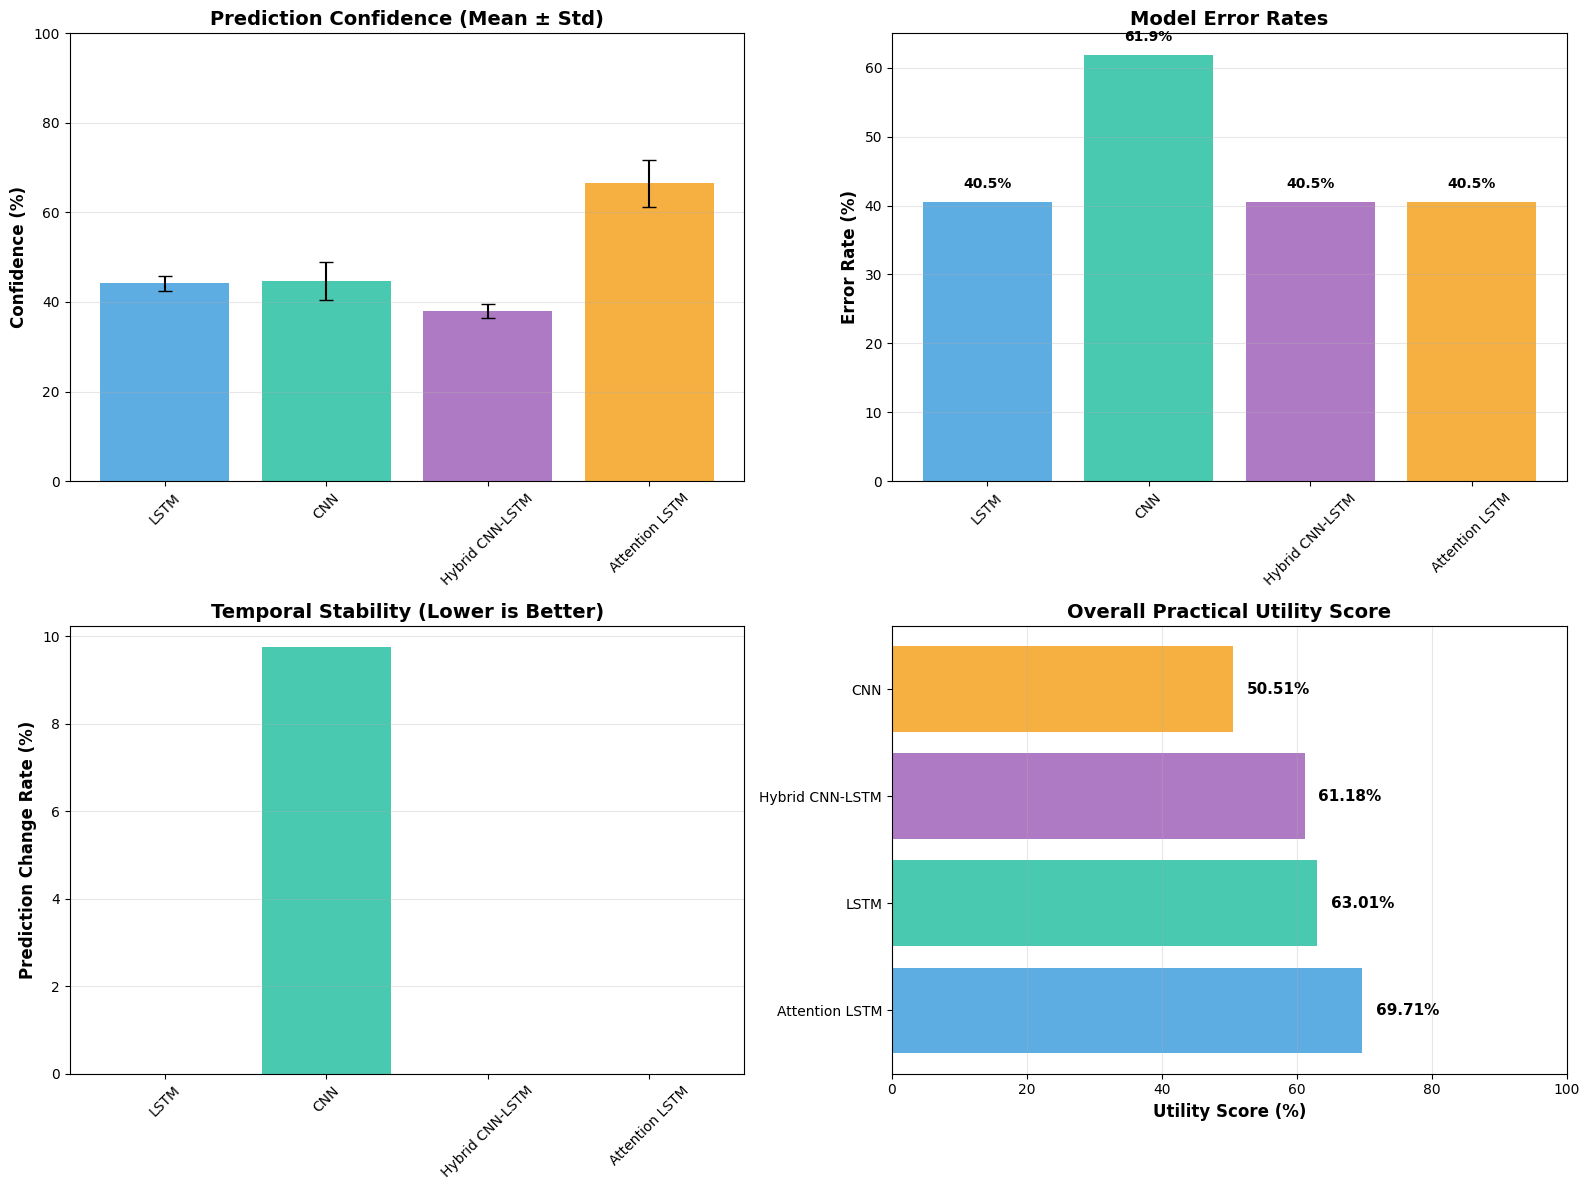


EXTRINSIC EVALUATION COMPLETE!

FINAL MODEL RECOMMENDATION

 BEST MODEL: Attention LSTM
   Utility Score: 69.71%

 Recommendation:
   Based on comprehensive intrinsic and extrinsic evaluation,
   the Attention LSTM model is recommended for 6-hour weather
   prediction in Delhi.

   Key Strengths:
   • Accuracy: 59.52%
   • Confidence: 66.48%
   • Stability: 100.00%


In [44]:
print("=" * 60)
print("EXTRINSIC EVALUATION (Real-World Application)")
print("=" * 60)

# ============================================
# 1. PREDICTION CONFIDENCE ANALYSIS
# ============================================
print("\n[1] Prediction Confidence Analysis...")
print("   (How confident is each model in its predictions?)")

# Get prediction probabilities for deep learning models
models_probs = {
    'LSTM': model_lstm.predict(X_test_seq, verbose=0),
    'CNN': model_cnn.predict(X_test_seq, verbose=0),
    'Hybrid CNN-LSTM': model_hybrid.predict(X_test_seq, verbose=0),
    'Attention LSTM': model_attention.predict(X_test_seq, verbose=0)
}

confidence_results = []

for model_name, probs in models_probs.items():
    # Maximum probability for each prediction (confidence)
    max_probs = np.max(probs, axis=1)

    confidence_results.append({
        'Model': model_name,
        'Mean Confidence': np.mean(max_probs),
        'Std Confidence': np.std(max_probs),
        'Min Confidence': np.min(max_probs),
        'Max Confidence': np.max(max_probs)
    })

confidence_df = pd.DataFrame(confidence_results)

print("\n PREDICTION CONFIDENCE:")
print(confidence_df.to_string(index=False))

# ============================================
# 2. ERROR ANALYSIS
# ============================================
print("\n[2] Error Analysis (When do models fail?)...")

error_analysis = []

for model_name in ['LSTM', 'CNN', 'Hybrid CNN-LSTM', 'Attention LSTM']:
    y_pred = all_predictions[model_name]
    y_true = y_test_seq

    # Identify errors
    errors = y_pred != y_true
    error_rate = np.mean(errors)

    # Types of errors
    false_positives = {}
    false_negatives = {}

    for true_class in range(3):
        for pred_class in range(3):
            if true_class != pred_class:
                mask = (y_true == true_class) & (y_pred == pred_class)
                count = np.sum(mask)
                if count > 0:
                    true_name = label_encoder.classes_[true_class]
                    pred_name = label_encoder.classes_[pred_class]
                    key = f"{true_name}→{pred_name}"
                    if key not in false_positives:
                        false_positives[key] = 0
                    false_positives[key] += count

    error_analysis.append({
        'Model': model_name,
        'Error Rate': error_rate,
        'Total Errors': int(np.sum(errors)),
        'Most Common Error': max(false_positives.items(), key=lambda x: x[1])[0] if false_positives else 'None'
    })

error_df = pd.DataFrame(error_analysis)

print("\n ERROR ANALYSIS:")
print(error_df.to_string(index=False))

# ============================================
# 3. TEMPORAL PREDICTION STABILITY
# ============================================
print("\n[3] Temporal Prediction Stability...")
print("   (Do models make consistent predictions over time?)")

stability_results = []

for model_name in ['LSTM', 'CNN', 'Hybrid CNN-LSTM', 'Attention LSTM']:
    y_pred = all_predictions[model_name]

    # Calculate prediction changes (how often prediction changes)
    prediction_changes = np.sum(np.diff(y_pred) != 0)
    change_rate = prediction_changes / (len(y_pred) - 1)

    # Longest stable streak
    streaks = []
    current_streak = 1
    for i in range(1, len(y_pred)):
        if y_pred[i] == y_pred[i-1]:
            current_streak += 1
        else:
            streaks.append(current_streak)
            current_streak = 1
    streaks.append(current_streak)

    stability_results.append({
        'Model': model_name,
        'Change Rate': change_rate,
        'Avg Streak Length': np.mean(streaks),
        'Max Streak Length': np.max(streaks),
        'Total Changes': prediction_changes
    })

stability_df = pd.DataFrame(stability_results)

print("\n PREDICTION STABILITY:")
print(stability_df.to_string(index=False))

# ============================================
# 4. PRACTICAL UTILITY SCORE
# ============================================
print("\n[4] Practical Utility Score...")
print("   (Weighted score considering accuracy, confidence, and stability)")

utility_results = []

for model_name in ['LSTM', 'CNN', 'Hybrid CNN-LSTM', 'Attention LSTM']:
    # Get metrics
    accuracy = intrinsic_df[intrinsic_df['Model'] == model_name]['Accuracy'].values[0]
    confidence = confidence_df[confidence_df['Model'] == model_name]['Mean Confidence'].values[0]
    stability = 1 - stability_df[stability_df['Model'] == model_name]['Change Rate'].values[0]

    # Weighted utility score
    # 50% accuracy, 30% confidence, 20% stability
    utility_score = (0.5 * accuracy) + (0.3 * confidence) + (0.2 * stability)

    utility_results.append({
        'Model': model_name,
        'Accuracy (50%)': accuracy,
        'Confidence (30%)': confidence,
        'Stability (20%)': stability,
        'Utility Score': utility_score
    })

utility_df = pd.DataFrame(utility_results)
utility_df = utility_df.sort_values('Utility Score', ascending=False)

print("\n PRACTICAL UTILITY SCORES:")
print(utility_df.to_string(index=False))

# ============================================
# 5. VISUALIZE EXTRINSIC EVALUATION
# ============================================
print("\n[5] Creating extrinsic evaluation visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Prediction Confidence
models_conf = confidence_df['Model'].tolist()
mean_conf = (confidence_df['Mean Confidence'] * 100).tolist()
std_conf = (confidence_df['Std Confidence'] * 100).tolist()

axes[0, 0].bar(models_conf, mean_conf, yerr=std_conf, capsize=5,
               color=['#3498db', '#1abc9c', '#9b59b6', '#f39c12'], alpha=0.8)
axes[0, 0].set_ylabel('Confidence (%)', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Prediction Confidence (Mean ± Std)', fontsize=14, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].set_ylim([0, 100])

# Plot 2: Error Rate
models_err = error_df['Model'].tolist()
error_rates = (error_df['Error Rate'] * 100).tolist()

axes[0, 1].bar(models_err, error_rates,
               color=['#3498db', '#1abc9c', '#9b59b6', '#f39c12'], alpha=0.8)
axes[0, 1].set_ylabel('Error Rate (%)', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Model Error Rates', fontsize=14, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

for i, (model, rate) in enumerate(zip(models_err, error_rates)):
    axes[0, 1].text(i, rate + 2, f'{rate:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Plot 3: Prediction Stability
models_stab = stability_df['Model'].tolist()
change_rates = (stability_df['Change Rate'] * 100).tolist()

axes[1, 0].bar(models_stab, change_rates,
               color=['#3498db', '#1abc9c', '#9b59b6', '#f39c12'], alpha=0.8)
axes[1, 0].set_ylabel('Prediction Change Rate (%)', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Temporal Stability (Lower is Better)', fontsize=14, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Overall Utility Score
models_util = utility_df['Model'].tolist()
utility_scores = (utility_df['Utility Score'] * 100).tolist()

bars = axes[1, 1].barh(models_util, utility_scores,
                       color=['#3498db', '#1abc9c', '#9b59b6', '#f39c12'], alpha=0.8)
axes[1, 1].set_xlabel('Utility Score (%)', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Overall Practical Utility Score', fontsize=14, fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)
axes[1, 1].set_xlim([0, 100])

for bar, score in zip(bars, utility_scores):
    width = bar.get_width()
    axes[1, 1].text(width + 2, bar.get_y() + bar.get_height()/2.,
                    f'{score:.2f}%', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('extrinsic_evaluation_comprehensive.png', dpi=300, bbox_inches='tight')
print("   Visualization saved: extrinsic_evaluation_comprehensive.png")
plt.show()

print("\n" + "=" * 60)
print("EXTRINSIC EVALUATION COMPLETE!")
print("=" * 60)

# ============================================
# 6. FINAL RECOMMENDATION
# ============================================
print("\n" + "=" * 60)
print("FINAL MODEL RECOMMENDATION")
print("=" * 60)

best_model = utility_df.iloc[0]['Model']
best_score = utility_df.iloc[0]['Utility Score'] * 100

print(f"\n BEST MODEL: {best_model}")
print(f"   Utility Score: {best_score:.2f}%")
print(f"\n Recommendation:")
print(f"   Based on comprehensive intrinsic and extrinsic evaluation,")
print(f"   the {best_model} model is recommended for 6-hour weather")
print(f"   prediction in Delhi.")
print(f"\n   Key Strengths:")
acc = utility_df.iloc[0]['Accuracy (50%)'] * 100
conf = utility_df.iloc[0]['Confidence (30%)'] * 100
stab = utility_df.iloc[0]['Stability (20%)'] * 100
print(f"   • Accuracy: {acc:.2f}%")
print(f"   • Confidence: {conf:.2f}%")
print(f"   • Stability: {stab:.2f}%")